In [1]:
# ==============================================================================
# 0. PERSAPAN LINGKUNGAN (ENVIRONMENT SETUP)
# ==============================================================================

# Library Dasar dan Manipulasi Data
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
# from tqdm import tqdm

# Visualisasi Data
import seaborn as sns
import matplotlib.pyplot as plt

# Natural Language Processing (NLP)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Machine Learning: Preprocessing & Ekstraksi Fitur
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Machine Learning: Penanganan Imbalance Data (SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Machine Learning: Model Naive Bayes & Optimasi
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

# Machine Learning: Evaluasi Performa
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Utility Tambahan
import kagglehub
import ast

# Inisialisasi Tqdm untuk Pandas
# tqdm.pandas()

# Tahap 1: Akuisisi & Eksplorasi Data
Stratified Sampling, Pelabelan Data, Analisis Imbalance dan Veracity awal.

In [2]:
# ==============================================================================
# TAHAP 1: AKUISISI DAN EKSPLORASI DATA
# ==============================================================================

# --- 1.1 Akuisisi Dataset dari Kaggle ---
# Mengunduh dataset ulasan produk Tokopedia menggunakan KaggleHub API
path = kagglehub.dataset_download('farhan999/tokopedia-product-reviews')
print('Direktori Dataset:', path)

# --- 1.2 Verifikasi Struktur File ---
# Mengecek ketersediaan file CSV di dalam direktori untuk memastikan proses unduh berhasil
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Direktori Dataset: /home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2
/home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2/tokopedia-product-reviews-2019.csv


## Memuat dan Inspeksi Data
<h4>Memastikan data terbaca dan mengidentifikasi kolom ulasan (text) dan kolom rating (label)

In [3]:
# --- 1.3 Pembacaan Data dan Konfigurasi Display ---

# Mengatur tampilan output Pandas agar data ulasan tidak terpotong saat inspeksi manual
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Mendefinisikan lokasi file CSV hasil unduhan
csv_file_path = os.path.join(path, 'tokopedia-product-reviews-2019.csv')

# Memuat dataset ke dalam DataFrame Pandas dengan pengecekan keberadaan file
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print(f"Berhasil memuat dataset. Total baris: {len(df)}")
    display(df.head())
else:
    print(f"Error: File tidak ditemukan di lokasi: {csv_file_path}")

Berhasil memuat dataset. Total baris: 40607


,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staples-dekorasi-staples-kayu-refill-8mm-staples-gun-4-8...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; OSSEL 1022J,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-staples-tembak-air-nailer-gun-ossel-1022j
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gun Max t3-10 mb MAX,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-refill-staples-jok-kulit-motor-staple-gun-max-t3-10-m...


In [4]:
# --- 1.4 Inspeksi Struktur Dataset dan Kualitas Data ---

# Menampilkan informasi detail mengenai tipe data dan penggunaan memori tiap kolom
print("=== STRUKTUR DATASET ===")
df.info()

# Mengecek keberadaan nilai kosong (Missing Values) pada setiap fitur
# Hal ini penting untuk memastikan integritas data sebelum proses pembersihan
print("\n=== PENGECEKAN DATA KOSONG (MISSING VALUES) ===")
print(df.isnull().sum())

=== STRUKTUR DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB

=== PENGECEKAN DATA KOSONG (MISSING VALUES) ===
Unnamed: 0       0
text             0
rating           0
category         0
product_name     0
product_id       0
sold            14
shop_id          0
product_url      0
dtype: int64


In [5]:
# --- 1.5 Pernyataan Total Populasi Data ---

total_ulasan = len(df)
print(f"Total Data Awal: {total_ulasan} ulasan")

Total Data Awal: 40607 ulasan


In [6]:
# --- 1.6 Pengambilan Sampel untuk Simulasi Perhitungan Manual (Bab III) ---

# Membuat salinan untuk analisis teks
df_simulasi = df.copy()

# Menghitung panjang ulasan (jumlah kata)
df_simulasi['num_words'] = df_simulasi['text'].apply(lambda x: len(str(x).split()))

# Mengambil 2 contoh ulasan POSITIF (Rating 5) untuk simulasi perhitungan manual
# Sampel ini akan digunakan untuk mendemonstrasikan proses TF-IDF dan Naive Bayes di Bab III
print("=== SAMPEL SIMULASI: SENTIMEN POSITIF (2 DATA) ===")
simulasi_positif = df_simulasi[(df_simulasi['rating'] == 5) & 
                               (df_simulasi['num_words'] >= 3) & 
                               (df_simulasi['num_words'] <= 6)][['text', 'rating']].head(2)
display(simulasi_positif)

print("\n" + "="*45 + "\n")

# Mengambil 1 contoh ulasan NEGATIF (Rating 1) untuk simulasi perhitungan manual
# Digunakan untuk melihat perbedaan pembobotan kata terhadap label yang berbeda
print("=== SAMPEL SIMULASI: SENTIMEN NEGATIF (1 DATA) ===")
simulasi_negatif = df_simulasi[(df_simulasi['rating'] == 1) & 
                               (df_simulasi['num_words'] >= 3) & 
                               (df_simulasi['num_words'] <= 6)][['text', 'rating']].head(1)
display(simulasi_negatif)

=== SAMPEL SIMULASI: SENTIMEN POSITIF (2 DATA) ===


,text,rating
0,Barang sesuai pesanan dan cepat sampai,5
1,Barang bagus harga murah,5




=== SAMPEL SIMULASI: SENTIMEN NEGATIF (1 DATA) ===


,text,rating
93,barang yg dikirim tidak sesuai pesanan,1


## Cek & Hapus Duplikasi

In [7]:
# --- 1.7 Eliminasi Data Redundan (Deduplikasi) ---

# Menghitung jumlah data awal sebelum penghapusan duplikat
initial_len = len(df)

# Menghapus ulasan yang memiliki teks identik (duplikat/spam)
# Data duplikat dapat menyebabkan bias pada model karena frekuensi kata yang tidak natural
df = df.drop_duplicates(subset='text')

# Mencatat statistik pembersihan data
print(f"Jumlah Data Duplikat/Spam Dihapus : {initial_len - len(df)}")
print(f"Total Data Unik Tersisa          : {len(df)} baris")

Jumlah Data Duplikat/Spam Dihapus : 3306
Total Data Unik Tersisa          : 37301 baris


## Pelabelan Ulang (Mapping Rating ke Sentimen)
<h4>Naive Bayes biasanya mengklasifikasikan ke 3 kelas (Positif, Netral, Negatif), kita perlu me-mapping rating (1-5) menjadi 3 kelas.</h4>

In [8]:
# --- 1.8 Pelabelan Data Otomatis (Rule-Based Labeling) ---

# Mendefinisikan fungsi pemetaan rating menjadi label sentimen
# Skala Likert 1-5 dikelompokkan ke dalam 3 kategori utama:
def map_sentiment(rating):
    # Rating 4 dan 5 dikategorikan sebagai sentimen positif (Kepuasan tinggi)
    if rating in [4, 5]:
        return 'Positif'
    # Rating 3 dikategorikan sebagai sentimen netral (Kepuasan moderat/ambigu)
    elif rating == 3:
        return 'Netral'
    # Rating 1 dan 2 dikategorikan sebagai sentimen negatif (Ketidakpuasan)
    elif rating in [1, 2]:
        return 'Negatif'

# Menerapkan fungsi pelabelan ke seluruh baris dataset
df['Sentiment_Label'] = df['rating'].apply(map_sentiment)

# Verifikasi hasil pelabelan dengan sampel acak
# Memastikan transisi dari kolom 'rating' ke 'Sentiment_Label' sudah akurat
print("=== VERIFIKASI HASIL PELABELAN SENTIMEN ===")
display(df[['rating', 'Sentiment_Label']].sample(5, random_state=42))

=== VERIFIKASI HASIL PELABELAN SENTIMEN ===


,rating,Sentiment_Label
22953,5,Positif
10746,5,Positif
17259,5,Positif
29219,5,Positif
5086,5,Positif


## Menghitung Distribusi Awal
<h4>Mendapatkan angka pasti untuk populasi sebelum sampling 20.000. Angka ini juga menunjukkan apakah terjadi Imbalance Class.</h4>

In [9]:
# --- 1.9 Analisis Distribusi Kelas Sentimen (Populasi Unik) ---

# Menghitung frekuensi absolut tiap label sentimen
dist_count = df['Sentiment_Label'].value_counts()

# Menghitung persentase proporsi tiap kelas untuk mengidentifikasi tingkat ketidakseimbangan data
dist_perc = df['Sentiment_Label'].value_counts(normalize=True) * 100

# Menggabungkan hasil analisis ke dalam DataFrame ringkasan agar mudah dibaca
dist_df = pd.DataFrame({
    'Jumlah': dist_count, 
    'Persentase (%)': dist_perc.round(2)
})

print("=== DISTRIBUSI SENTIMEN PADA DATA POPULASI (UNIK) ===")
display(dist_df)

# Catatan: Perbedaan yang sangat jauh antara kelas 'Positif' dan 'Negatif/Netral' 
# mengindikasikan adanya 'Imbalanced Data' yang akan ditangani pada tahap pemodelan.

=== DISTRIBUSI SENTIMEN PADA DATA POPULASI (UNIK) ===


,Jumlah,Persentase (%)
Sentiment_Label,,
Positif,34628,92.83
Netral,1762,4.72
Negatif,911,2.44


## Stratified Sampling ke 20.000 Sampel
<h4>Mengambil sampel 20.000 data yang proporsi sentimennya sama dengan data 40.000 awal (ini adalah teknik Stratified Sampling)</h4>

In [10]:
# --- 1.10 Reduksi Dimensi Dataset (Stratified Sampling) ---

# Menentukan target jumlah sampel untuk efisiensi komputasi tanpa menghilangkan karakteristik data
N_TARGET = 20000

if len(df) > N_TARGET:
    # Menghitung rasio data yang akan dialokasikan ke sampel target
    test_size_ratio = 1 - (N_TARGET / len(df))

    # Menggunakan Stratified Sampling untuk menjaga proporsi label sentimen tetap konsisten
    # Random_state=42 digunakan agar hasil sampling dapat direplikasi (Reproducibility)
    print(f"Melakukan Stratified Sampling dari {len(df)} ke {N_TARGET} data...")
    df_sample, _ = train_test_split(
        df,
        test_size=test_size_ratio,
        random_state=42,
        stratify=df['Sentiment_Label']
    )
    print("Proses Sampling Berhasil.")
else:
    # Jika data unik sudah di bawah target, maka seluruh data akan digunakan
    print(f"Data unik ({len(df)}) < {N_TARGET}, menggunakan seluruh data yang tersedia.")
    df_sample = df.copy()

Melakukan Stratified Sampling dari 37301 ke 20000 data...
Proses Sampling Berhasil.


## Cleaning Ringan & Visualisasi Distribusi

In [11]:
# --- 1.11 Seleksi Fitur dan Finalisasi Data Sampel ---

# Menampilkan jumlah kolom awal sebelum penyaringan
print(f"Jumlah kolom sebelum seleksi: {len(df_sample.columns)}")

# Menyeleksi hanya kolom yang relevan untuk kebutuhan analisis sentimen
# 'text': Fitur utama (X), 'Sentiment_Label': Target prediksi (y), 'rating': Referensi awal
df_sample = df_sample[['text', 'rating', 'Sentiment_Label']].copy()

# Melakukan reset index agar urutan data kembali konsisten setelah proses sampling
df_sample = df_sample.reset_index(drop=True)

print(f"Jumlah kolom setelah seleksi: {len(df_sample.columns)}")
print("\n=== DATA SAMPEL AKHIR (SIAP UNTUK PREPROCESSING) ===")
display(df_sample.head())

Jumlah kolom sebelum seleksi: 10
Jumlah kolom setelah seleksi: 3

=== DATA SAMPEL AKHIR (SIAP UNTUK PREPROCESSING) ===


,text,rating,Sentiment_Label
0,Barang sesuai orderan dan kondisi bagus,5,Positif
1,Nice gan keren produknya. Maju terus yaaaa,5,Positif
2,Baranh bagus.cma blm bisa merangkainya,5,Positif
3,barangnya bagus sesuai harga...,4,Positif
4,"Barang sdh mendarat dgn slmt, sedikit kecewa sih, ordernya merk firlan dikirimnya merk fleco..",4,Positif


=== TABEL DISTRIBUSI SENTIMEN (SAMPEL 20.000 DATA) ===


,Sentimen,Jumlah,Persentase
0,Positif,18567,92.84
1,Netral,945,4.72
2,Negatif,488,2.44


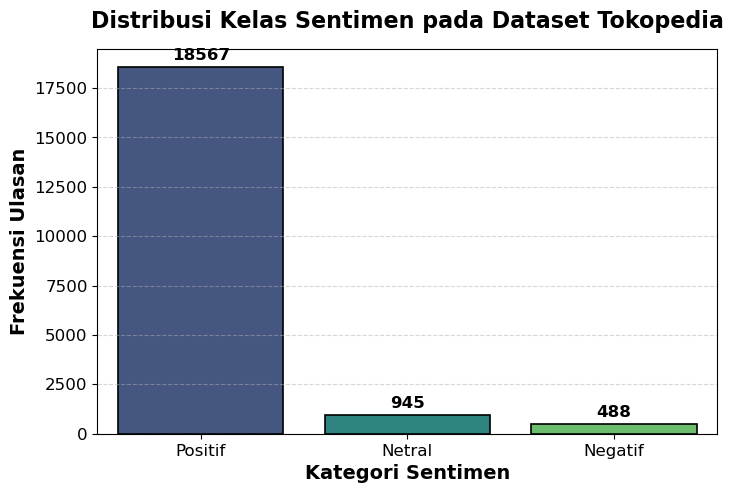

In [12]:
# --- 1.12 Visualisasi Distribusi Kelas (Identifikasi Class Imbalance) ---

# 1. Menghitung ringkasan statistik distribusi sentimen pada data sampel
dist_df = df_sample['Sentiment_Label'].value_counts().reset_index()
dist_df.columns = ['Sentimen', 'Jumlah']
dist_df['Persentase'] = (dist_df['Jumlah'] / len(df_sample)) * 100

print("=== TABEL DISTRIBUSI SENTIMEN (SAMPEL 20.000 DATA) ===")
display(dist_df.round(2))

# 2. Visualisasi Grafik Batang untuk memperjelas gap antar kelas
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Sentimen', 
    y='Jumlah', 
    data=dist_df, 
    hue='Sentimen', 
    palette='viridis', 
    legend=False, 
    edgecolor='black', 
    linewidth=1.2
)

# Pengaturan label dan judul grafik
plt.title('Distribusi Kelas Sentimen pada Dataset Tokopedia', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Kategori Sentimen', fontsize=14, fontweight='bold')
plt.ylabel('Frekuensi Ulasan', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)

for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)

In [15]:
# --- 1.13 Ekspor Data Sampel dan Validasi Integritas ---

# 1. Penyimpanan Data (Checkpoint)
# Menyimpan data sampel 20.000 ulasan ke dalam format CSV agar hasil sampling konsisten
df_sample.to_csv('data_sample_20k.csv', index=False)
print("Pesan: Data sampel berhasil diamankan ke 'data_sample_20k.csv'")

# 2. Pemuatan Kembali dan Validasi Data
# Tahap ini memastikan data yang tersimpan dapat terbaca kembali dengan benar
print("Sedang memuat kembali data sampel untuk validasi...")
df_sample = pd.read_csv('data_sample_20k.csv')

# 3. Penanganan Nilai Kosong (Handling Missing Values)
# Menghapus baris yang memiliki nilai NaN pada kolom teks atau label untuk menghindari error NLP
initial_len = len(df_sample)
df_sample = df_sample.dropna(subset=['text', 'Sentiment_Label'])

# Memastikan tipe data pada kolom ulasan adalah string (untuk proses tokenisasi)
df_sample['text'] = df_sample['text'].astype(str)

# 4. Ringkasan Status Kesiapan Data
if len(df_sample) != initial_len:
    print(f"Info: {initial_len - len(df_sample)} baris NaN ditemukan dan telah dibersihkan.")
else:
    print("Info: Integritas data terjaga, tidak ditemukan nilai NaN.")

print(f"Total Data Siap Masuk Tahap Preprocessing: {len(df_sample)} baris")
display(df_sample.head())

Pesan: Data sampel berhasil diamankan ke 'data_sample_20k.csv'
Sedang memuat kembali data sampel untuk validasi...
Info: Integritas data terjaga, tidak ditemukan nilai NaN.
Total Data Siap Masuk Tahap Preprocessing: 20000 baris


,text,rating,Sentiment_Label
0,Barang sesuai orderan dan kondisi bagus,5,Positif
1,Nice gan keren produknya. Maju terus yaaaa,5,Positif
2,Baranh bagus.cma blm bisa merangkainya,5,Positif
3,barangnya bagus sesuai harga...,4,Positif
4,"Barang sdh mendarat dgn slmt, sedikit kecewa sih, ordernya merk firlan dikirimnya merk fleco..",4,Positif


# Tahap 2: Pra-pemrosesan Data dan Rekayasa Fitur

## A. Preprocessing

### 1. Mencari Kata Slang

In [14]:
# ==============================================================================
# TAHAP 2: TEXT PREPROCESSING (PEMBERSIHAN DATA TEKS)
# ==============================================================================

# --- 2.1 Identifikasi Karakteristik Kata Slang (Observasi Data) ---

# Mendefinisikan fungsi pembersihan cepat (light cleaning) untuk analisis frekuensi
def quick_clean_check(text):
    # Mengubah teks menjadi huruf kecil
    text = str(text).lower()
    # Menghapus seluruh karakter non-huruf (angka dan simbol)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Menghapus spasi berlebih
    return re.sub(r'\s+', ' ', text).strip()

# Menerapkan pembersihan ringan pada dataset sampel ulasan
print("Sedang memproses teks dan menghitung frekuensi kata...")
all_text_sample = df_sample['text'].apply(quick_clean_check)

# Menggabungkan seluruh teks menjadi satu kumpulan kata (corpus)
all_words = ' '.join(all_text_sample).split()

# Menghitung kemunculan (frekuensi) setiap kata menggunakan Counter
word_counts = Counter(all_words)

# Menyimpan 500 kata yang paling sering muncul ke dalam DataFrame analisis
df_top_500 = pd.DataFrame(word_counts.most_common(500), columns=['Kata', 'Frekuensi'])

print("--- ANALISIS TOP 500 KATA UNTUK PENYUSUNAN KAMUS SLANG ---")

# Menampilkan hasil frekuensi kata per blok (batch) untuk memudahkan peninjauan manual
# Data ini digunakan sebagai landasan dalam menentukan entri pada Kamus Slang
for i in range(0, 500, 50):
    print(f"\n>>> Peringkat {i+1} sampai {i+50} <<<")
    print(df_top_500.iloc[i : i+50])
    print("-" * 45)

Sedang memproses teks dan menghitung frekuensi kata...
--- ANALISIS TOP 500 KATA UNTUK PENYUSUNAN KAMUS SLANG ---

>>> Peringkat 1 sampai 50 <<<
           Kata  Frekuensi
0        barang       7643
1        sesuai       5640
2         cepat       4474
3           dan       4100
4         bagus       3836
5        dengan       2723
6         sudah       2664
7    pengiriman       2296
8        sampai       2265
9          baik       2109
10       terima       2030
11       respon       1971
12          gan       1908
13           di       1850
14        kasih       1627
15       produk       1600
16       seller       1501
17      pesanan       1496
18       mantap       1476
19          nya       1375
20     diterima       1294
21    deskripsi       1291
22      packing       1252
23           ok       1212
24           yg       1202
25       thanks       1094
26         saya       1021
27    barangnya       1003
28       sangat        930
29          oke        920
30        harga   

### 2. Membuat Kamus Slang (Berdasarkan Frekuensi Kata)

In [15]:
# --- 2.2 Penyusunan Kamus Normalisasi Slang (Slang Dictionary) ---

# Mendefinisikan pemetaan (mapping) dari kata informal/typo ke bentuk baku bahasa Indonesia.
# Kamus ini disusun secara manual berdasarkan hasil analisis frekuensi pada tahap sebelumnya.
slang_data = {
    'slang': [
        # --- KELOMPOK 1: Singkatan & Typo Dominan (Berdasarkan Frekuensi Teratas) ---
        'd', 'dg', 'jg', 'n', 'tq', 'tks', 'aja', 'deh', 'udh', 'yg', 'dgn', 'gak', 'ga', 
        'krn', 'sdh', 'blm', 'thx', 'brg', 'ori', 'bgs', 'mantul', 'mantab', 'gan', 'sis', 
        'kak', 'bs', 'sy', 'tp', 'kalo', 'kl', 'karna', 'responya', 'packing', 'cepet', 
        'sampe', 'trims', 'recomended', 'recommended', 'kwalitas', 'makasih', 'pake', 
        'bgt', 'dr', 'dtg', 'rapih', 'oke', 'ok', 'udah', 'nyampe', 'pokoknya', 'bos', 
        'sip', 'klo', 'nich', 'cuman', 'boossku', 'bosku', 'retur', 'work', 'respon', 
        'resp', 'ttp', 'smpai', 'barng', 'kuy', 'jgn', 'luarbiasa', 'gk', 'blom', 'ngak', 
        'sesua', 'tdk', 'seblm', 'donk', 'trmksh', 'y', 'smpe', 'pekingnya', 'gapapa', 
        'th', 'packingan', 'ato', 'mantapppppppppp', 'gannmmmmnmnn', 'brgnya', 'cpt', 
        'utk', 'jd', 'sih', 'an', 'respond', 'overall', 'and', 'hp', 'alhamdulillah', 
        'disini', 'thanks', 'thank', 'fast', 'good', 'seller', 'best', 'slow', 'refund', 
        'response', 'original', 'product', 'you', 'the power', 'delivery', 'amp', 'pdhl',

        # --- KELOMPOK 2: Variasi Sapaan, Kualitas, & Transaksi ---
        'trimakasih', 'trima', 'mksh', 'makasi', 'thankyou', 'agan', 'boss', 'om', 'bro',
        'lg', 'moga', 'smoga', 'mudahan', 'dlm', 'tpi', 'tgl', 'dpt', 'dapet', 'cm', 'g', 
        'u', 'it', 'ane', 'gpp', 'ny', 'tu', 'quality', 'baguss', 'bagusss', 'bgus', 'sipp', 
        'joss', 'markotop', 'mantaap', 'mantapp', 'mantep', 'great', 'nice', 'okelah', 'mnrt',
        'service', 'pesen', 'orderan', 'kiriman', 'sampenya', 'trus', 'dikirim', 'ngirim', 
        'recomend', 'rekomen', 'review', 'nyesel', 'sorry', 'rusak', 'error', 'kcwa', 
        'kecewa', 'ancur', 'brng', 'diskripsi', 'kabel', 'batre', 'baterai', 'cassan', 
        'casan', 'ksh', 'kaya', 'ak', 'aq'
    ],
    'formal': [
        # --- MAPPING KELOMPOK 1 ---
        'di', 'dengan', 'juga', 'dan', 'terima kasih', 'terima kasih', 'saja', 'saja', 'sudah', 
        'yang', 'dengan', 'tidak', 'tidak', 'karena', 'sudah', 'belum', 'terima kasih', 
        'barang', 'asli', 'bagus', 'mantap betul', 'mantap', 'juragan', 'kakak', 'kakak', 
        'bisa', 'saya', 'tapi', 'kalau', 'kalau', 'karena', 'responnya', 'pengemasan', 
        'cepat', 'sampai', 'terima kasih', 'rekomendasi', 'rekomendasi', 'kualitas', 
        'terima kasih', 'pakai', 'banget', 'dari', 'datang', 'rapi', 'baik', 'baik', 
        'sudah', 'sampai', 'memang', 'juragan', 'bagus', 'kalau', 'ini', 'cuma', 
        'juragan', 'juragan', 'pengembalian', 'berfungsi', 'respons', 'respons', 'tetap', 
        'sampai', 'barang', 'yuk', 'jangan', 'luar biasa', 'tidak', 'belum', 'tidak', 
        'sesuai', 'tidak', 'sebelum', 'dong', 'terima kasih', 'ya', 'sampai', 'pengemasannya', 
        'tidak apa-apa', 'tahun', 'pengemasan', 'atau', 'mantap', 'juragan', 'barang', 
        'cepat', 'untuk', 'jadi', 'saja', 'an', 'respons', 'secara keseluruhan', 'dan', 'handphone', 
        'bersyukur', 'di sini', 'terima kasih', 'terima kasih', 'cepat', 'bagus', 
        'penjual', 'terbaik', 'lambat', 'pengembalian dana', 'respons', 'asli', 
        'produk', 'anda', 'kekuatan', 'pengiriman', 'dan', 'padahal',

        # --- MAPPING KELOMPOK 2 ---
        'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'juragan', 
        'juragan', 'paman', 'saudara', 'lagi', 'semoga', 'semoga', 'semoga', 'dalam', 'tapi', 
        'tanggal', 'dapat', 'dapat', 'cuma', 'tidak', 'kamu', 'itu', 'saya', 'tidak apa-apa', 
        'nya', 'itu', 'kualitas', 'bagus', 'bagus', 'bagus', 'sip', 'mantap', 'mantap', 
        'mantap', 'mantap', 'mantap', 'bagus', 'bagus', 'oke', 'menurut', 'layanan', 'pesan', 
        'pesanan', 'pengiriman', 'sampainya', 'terus', 'kirim', 'kirim', 'rekomendasi', 
        'rekomendasi', 'ulasan', 'menyesal', 'maaf', 'rusak', 'rusak', 'kecewa', 'kecewa', 
        'hancur', 'barang', 'deskripsi', 'kabel', 'baterai', 'baterai', 'charger', 'charger', 
        'kasih', 'seperti', 'aku', 'aku'
    ]
}

# --- 2.3 Validasi, Penyimpanan, dan Inisialisasi Dictionary ---

# Memastikan jumlah kunci (slang) dan nilai (formal) selaras untuk mencegah error indeks
if len(slang_data['slang']) != len(slang_data['formal']):
    print(f"FATAL ERROR: Ketidaksamaan jumlah entri! Slang: {len(slang_data['slang'])}, Formal: {len(slang_data['formal'])}")
else:
    # Menyimpan kamus ke CSV untuk portabilitas dan dokumentasi lampiran skripsi
    pd.DataFrame(slang_data).to_csv('kamus_slang_skripsi.csv', index=False)
    
    # Memuat kembali dan melakukan normalisasi (lowercase & strip spasi)
    df_slang_load = pd.read_csv('kamus_slang_skripsi.csv')
    df_slang_load['slang'] = df_slang_load['slang'].astype(str).str.strip().str.lower()
    df_slang_load['formal'] = df_slang_load['formal'].astype(str).str.strip().str.lower()
    
    # Filter entri slang yang mengandung spasi (untuk efisiensi token-level mapping)
    df_slang_load = df_slang_load[~df_slang_load['slang'].str.contains(r'\s+')]
    
    # Mengonversi DataFrame menjadi Python Dictionary untuk kecepatan lookup saat preprocessing
    SLANG_DICT = dict(zip(df_slang_load['slang'], df_slang_load['formal']))
    print(f"Kamus siap digunakan! Total kosakata unik: {len(SLANG_DICT)}")

Kamus siap digunakan! Total kosakata unik: 180


### 3. Eksekusi Preprocessing Utama

In [ ]:
# ==============================================================================
# TAHAP 2:  TEXT PREPROCESSING (2 VARIAN PARALEL)
# ==============================================================================

# --- 2.4 Definisi Fungsi Preprocessing (2 Varian) ---

# Pre-compiling Regex Patterns untuk meningkatkan kecepatan eksekusi
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HTML_PATTERN = re.compile(r'<.*?>|&([a-z0-9]+|#[0-9]{1,6});')
NON_ALPHA_PATTERN = re.compile(r'[^a-z\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')

# VARIAN 1: DENGAN NORMALISASI SLANG
def preprocessing_with_slang(text):
    """
    Preprocessing lengkap DENGAN tahap normalisasi slang menggunakan SLANG_DICT. 
    Digunakan untuk mengukur dampak slang normalization terhadap performa model.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)
    
    # TAHAP NORMALISASI SLANG (AKTIF)
    words = text.split()
    normalized_words = [SLANG_DICT.get(word, word) for word in words]
    text = ' '.join(normalized_words)
    
    text = WHITESPACE_PATTERN. sub(' ', text).strip()
    return text

# VARIAN 2: TANPA NORMALISASI SLANG
def preprocessing_without_slang(text):
    """
    Preprocessing lengkap TANPA tahap normalisasi slang. 
    Digunakan sebagai baseline untuk analisis ablasi.
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    text = re.sub(r'([a-z])\1+', r'\1\1', text)
    
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    return text

print("Fungsi preprocessing (2 varian) berhasil didefinisikan.")

Fungsi preprocessing (2 varian) berhasil didefinisikan.


In [17]:
# --- 2.5 Eksekusi Preprocessing pada Dataset Sampel (2 Pipeline Paralel) ---

print("Memulai preprocessing VARIAN 1 (Dengan Normalisasi Slang)...")
df_sample['text_clean_WITH_slang'] = df_sample['text']. apply(preprocessing_with_slang)

print("Memulai preprocessing VARIAN 2 (Tanpa Normalisasi Slang)...")
df_sample['text_clean_NO_slang'] = df_sample['text'].apply(preprocessing_without_slang)

print("Kedua varian preprocessing selesai.\n")

# --- 2.6 Verifikasi Hasil Preprocessing (Komparasi Side-by-Side) ---

pd.set_option('display.max_colwidth', 120)

print("=== KOMPARASI:  WITH SLANG NORMALIZATION vs WITHOUT SLANG NORMALIZATION ===")

# Filter sampel yang mengandung kata slang untuk validasi efektivitas mapping
cek_sample = df_sample[df_sample['text']. str.contains('brg|yg|gan|gak|udh', case=False, na=False)]. head(5)

display(cek_sample[['text', 'text_clean_WITH_slang', 'text_clean_NO_slang']])

# --- 2.7 Audit Integritas Data Pasca-Cleaning ---

empty_with_slang = df_sample[df_sample['text_clean_WITH_slang'] == '']. shape[0]
empty_no_slang = df_sample[df_sample['text_clean_NO_slang'] == ''].shape[0]

print(f"\nAudit Log:")
print(f"- Data kosong (WITH slang normalization): {empty_with_slang} baris")
print(f"- Data kosong (NO slang normalization)  : {empty_no_slang} baris")

Memulai preprocessing VARIAN 1 (Dengan Normalisasi Slang)...
Memulai preprocessing VARIAN 2 (Tanpa Normalisasi Slang)...
Kedua varian preprocessing selesai.

=== KOMPARASI:  WITH SLANG NORMALIZATION vs WITHOUT SLANG NORMALIZATION ===


,text,text_clean_WITH_slang,text_clean_NO_slang
1,Nice gan keren produknya. Maju terus yaaaa,bagus juragan keren produknya maju terus yaa,nice gan keren produknya maju terus yaa
5,Barang bagus. Respon cepat. Thx gan,barang bagus respons cepat terima kasih juragan,barang bagus respon cepat thx gan
9,Terima barang dengan lengkap,terima barang dengan lengkap,terima barang dengan lengkap
13,barang sudah sampai gan terimakasih (y),barang sudah sampai juragan terimakasih ya,barang sudah sampai gan terimakasih y
18,Sesuai dengan foto Dan sangat cepat,sesuai dengan foto dan sangat cepat,sesuai dengan foto dan sangat cepat



Audit Log:
- Data kosong (WITH slang normalization): 63 baris
- Data kosong (NO slang normalization)  : 63 baris


In [19]:
# --- 2.8 Pembersihan Akhir Baris Kosong (Filtering Invalid Data) ---

initial_len = len(df_sample)
print(f"Jumlah sampel awal: {initial_len}")

# Mengonversi string kosong menjadi NaN untuk kedua varian
df_sample['text_clean_WITH_slang'] = df_sample['text_clean_WITH_slang'].replace('', np.nan)
df_sample['text_clean_NO_slang'] = df_sample['text_clean_NO_slang'].replace('', np.nan)

# Menghapus baris yang kosong di SALAH SATU atau KEDUA kolom
df_sample = df_sample.dropna(subset=['text_clean_WITH_slang', 'text_clean_NO_slang'])
df_sample = df_sample.reset_index(drop=True)

print(f"Jumlah sampel valid: {len(df_sample)}")
print(f"Data yang berhasil dibersihkan: {initial_len - len(df_sample)} baris")

Jumlah sampel awal: 20000
Jumlah sampel valid: 19937
Data yang berhasil dibersihkan: 63 baris


### 5. Tokenisasi & Stopword Removal

In [20]:
# --- 2.9 Tahap Filtering (Stopword Removal) & Tokenisasi (2 Varian Paralel) ---

# Memastikan resource NLTK tersedia di sistem
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# Inisialisasi daftar stopword bahasa Indonesia standar
stop_words = set(stopwords. words('indonesian'))

# Modifikasi Stopword:  Mempertahankan Kata Negasi
negation_keep = {'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang'}
for word in negation_keep:
    if word in stop_words:
        stop_words.remove(word)

# Penambahan Stopword Kustom
custom_stopwords = [
    'nya', 'an', 'deh', 'amp', 'ya', 'a', 'sih', 'dong', 'tuh', 
    'lah', 'pun', 'yuk', 'yang', 'dan', 'di', 'ke', 'dari', 'dg', 'rt'
]
stop_words.update(custom_stopwords)

def remove_stopwords(text):
    """
    Melakukan tokenisasi teks dan memfilter kata-kata yang masuk dalam daftar stopword.
    """
    if not isinstance(text, str):
        return []
    
    tokens = word_tokenize(text)
    filtered_words = [w for w in tokens if w not in stop_words]
    
    return filtered_words

# --- 2.10 Eksekusi Filtering pada Dataset (2 Pipeline) ---

print(f"Memulai proses tokenisasi & filtering VARIAN 1 (WITH slang)...")
df_sample['tokens_WITH_slang'] = df_sample['text_clean_WITH_slang'].apply(remove_stopwords)

print(f"Memulai proses tokenisasi & filtering VARIAN 2 (NO slang)...")
df_sample['tokens_NO_slang'] = df_sample['text_clean_NO_slang'].apply(remove_stopwords)

print(f"\nProses tokenisasi selesai.  Total Stopwords: {len(stop_words)} kata")

print("\n=== VERIFIKASI HASIL TOKENISASI & STOPWORD REMOVAL ===")
display(df_sample[['text_clean_WITH_slang', 'tokens_WITH_slang', 
                   'text_clean_NO_slang', 'tokens_NO_slang']].head(3))

Memulai proses tokenisasi & filtering VARIAN 1 (WITH slang)...
Memulai proses tokenisasi & filtering VARIAN 2 (NO slang)...

Proses tokenisasi selesai.  Total Stopwords: 762 kata

=== VERIFIKASI HASIL TOKENISASI & STOPWORD REMOVAL ===


,text_clean_WITH_slang,tokens_WITH_slang,text_clean_NO_slang,tokens_NO_slang
0,barang sesuai pesanan dan kondisi bagus,"[barang, sesuai, pesanan, kondisi, bagus]",barang sesuai orderan dan kondisi bagus,"[barang, sesuai, orderan, kondisi, bagus]"
1,bagus juragan keren produknya maju terus yaa,"[bagus, juragan, keren, produknya, maju, yaa]",nice gan keren produknya maju terus yaa,"[nice, gan, keren, produknya, maju, yaa]"
2,baranh bagus cma belum bisa merangkainya,"[baranh, bagus, cma, belum, merangkainya]",baranh bagus cma blm bisa merangkainya,"[baranh, bagus, cma, blm, merangkainya]"


### 6. Stemming (Sastrawi)

In [21]:
# --- 2.11 Optimasi Stemming (Dictionary-Based Stemming - 2 Varian Paralel) ---

# Inisialisasi Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# ============================================================================
# VARIAN 1: STEMMING UNTUK DATA DENGAN NORMALISASI SLANG
# ============================================================================

print("Mengumpulkan kosakata unik dari dataset (VARIAN 1: WITH slang)...")
all_tokens_with = [word for tokens in df_sample['tokens_WITH_slang'] for word in tokens]
unique_tokens_with = list(set(all_tokens_with))
print(f"Total kosakata unik (WITH slang normalization): {len(unique_tokens_with)} kata")

print("Memulai proses Stemming VARIAN 1...")
stemmed_dict_with = {}
for i, word in enumerate(unique_tokens_with):
    stemmed_dict_with[word] = stemmer.stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_with)}")
print(f"Selesai.  Total:  {len(stemmed_dict_with)} kata")

def apply_stemming_with(tokens):
    return [stemmed_dict_with[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 1)...")
df_sample['stemmed_list_WITH_slang'] = df_sample['tokens_WITH_slang'].apply(apply_stemming_with)

# ============================================================================
# VARIAN 2: STEMMING UNTUK DATA TANPA NORMALISASI SLANG
# ============================================================================

print("\nMengumpulkan kosakata unik dari dataset (VARIAN 2: NO slang)...")
all_tokens_no = [word for tokens in df_sample['tokens_NO_slang'] for word in tokens]
unique_tokens_no = list(set(all_tokens_no))
print(f"Total kosakata unik (NO slang normalization): {len(unique_tokens_no)} kata")

print("Memulai proses Stemming VARIAN 2...")
stemmed_dict_no = {}
for i, word in enumerate(unique_tokens_no):
    stemmed_dict_no[word] = stemmer. stem(word)
    if (i + 1) % 1000 == 0:
        print(f"  Progress: {i + 1}/{len(unique_tokens_no)}")
print(f"Selesai.  Total: {len(stemmed_dict_no)} kata")

def apply_stemming_no(tokens):
    return [stemmed_dict_no[word] for word in tokens]

print("Menerapkan hasil stemming ke dalam dataset (VARIAN 2)...")
df_sample['stemmed_list_NO_slang'] = df_sample['tokens_NO_slang'].apply(apply_stemming_no)

# --- 2.12 Finalisasi Teks (Detokenisasi - 2 Varian) ---

df_sample['text_final_WITH_slang'] = df_sample['stemmed_list_WITH_slang']. apply(lambda x: ' '.join(x))
df_sample['text_final_NO_slang'] = df_sample['stemmed_list_NO_slang']. apply(lambda x: ' '.join(x))

print("\n=== ANALISIS DAMPAK NORMALISASI SLANG TERHADAP VOCABULARY ===")
print(f"Jumlah kata unik SEBELUM stemming:")
print(f"  - WITH slang normalization: {len(unique_tokens_with):,} kata")
print(f"  - NO slang normalization  : {len(unique_tokens_no):,} kata")
print(f"  - Selisih (Reduksi)       : {len(unique_tokens_no) - len(unique_tokens_with):,} kata")

print("\n=== PERBANDINGAN DATA AKHIR (READY FOR MODELING) ===")
display(df_sample[['text_clean_WITH_slang', 'text_final_WITH_slang', 
                   'text_clean_NO_slang', 'text_final_NO_slang']]. head(3))

Mengumpulkan kosakata unik dari dataset (VARIAN 1: WITH slang)...
Total kosakata unik (WITH slang normalization): 8684 kata
Memulai proses Stemming VARIAN 1...
  Progress: 1000/8684
  Progress: 2000/8684
  Progress: 3000/8684
  Progress: 4000/8684
  Progress: 5000/8684
  Progress: 6000/8684
  Progress: 7000/8684
  Progress: 8000/8684
Selesai.  Total:  8684 kata
Menerapkan hasil stemming ke dalam dataset (VARIAN 1)...

Mengumpulkan kosakata unik dari dataset (VARIAN 2: NO slang)...
Total kosakata unik (NO slang normalization): 8842 kata
Memulai proses Stemming VARIAN 2...
  Progress: 1000/8842
  Progress: 2000/8842
  Progress: 3000/8842
  Progress: 4000/8842
  Progress: 5000/8842
  Progress: 6000/8842
  Progress: 7000/8842
  Progress: 8000/8842
Selesai.  Total: 8842 kata
Menerapkan hasil stemming ke dalam dataset (VARIAN 2)...

=== ANALISIS DAMPAK NORMALISASI SLANG TERHADAP VOCABULARY ===
Jumlah kata unik SEBELUM stemming:
  - WITH slang normalization: 8,684 kata
  - NO slang normalizat

,text_clean_WITH_slang,text_final_WITH_slang,text_clean_NO_slang,text_final_NO_slang
0,barang sesuai pesanan dan kondisi bagus,barang sesuai pesan kondisi bagus,barang sesuai orderan dan kondisi bagus,barang sesuai order kondisi bagus
1,bagus juragan keren produknya maju terus yaa,bagus juragan keren produk maju yaa,nice gan keren produknya maju terus yaa,nice gan keren produk maju yaa
2,baranh bagus cma belum bisa merangkainya,baranh bagus cma belum rangka,baranh bagus cma blm bisa merangkainya,baranh bagus cma blm rangka


In [22]:
# --- 2.13 Finalisasi dan Penyimpanan Dataset Hasil Preprocessing (2 File Terpisah) ---

# Kolom esensial yang akan disimpan
columns_base = ['text', 'rating', 'Sentiment_Label']

# ============================================================================
# DATASET 1: DENGAN NORMALISASI SLANG
# ============================================================================

df_with_slang = df_sample[columns_base + ['text_final_WITH_slang']].copy()
df_with_slang. rename(columns={'text_final_WITH_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_with_slang = df_with_slang[df_with_slang['text_final'].str.strip() != '']
df_with_slang = df_with_slang.dropna(subset=['text_final'])
df_with_slang = df_with_slang.reset_index(drop=True)

filename_with = 'data_WITH_slang_normalization.csv'
df_with_slang.to_csv(filename_with, index=False)

print(f"Dataset WITH Slang Normalization:")
print(f"  - File: {filename_with}")
print(f"  - Dimensi: {df_with_slang.shape}")
print(f"  - Kolom: {list(df_with_slang. columns)}")

# ============================================================================
# DATASET 2: TANPA NORMALISASI SLANG
# ============================================================================

df_no_slang = df_sample[columns_base + ['text_final_NO_slang']].copy()
df_no_slang.rename(columns={'text_final_NO_slang': 'text_final'}, inplace=True)

# Validasi dan pembersihan data kosong
df_no_slang = df_no_slang[df_no_slang['text_final'].str. strip() != '']
df_no_slang = df_no_slang.dropna(subset=['text_final'])
df_no_slang = df_no_slang.reset_index(drop=True)

filename_no = 'data_NO_slang_normalization.csv'
df_no_slang.to_csv(filename_no, index=False)

print(f"\nDataset WITHOUT Slang Normalization:")
print(f"  - File: {filename_no}")
print(f"  - Dimensi:  {df_no_slang. shape}")
print(f"  - Kolom: {list(df_no_slang.columns)}")

print("\n" + "="*70)
print("STATUS:  Proses Preprocessing Selesai Secara Menyeluruh (2 Varian)")
print("="*70)
print(f"Total file tersimpan: 2")
print(f"  1. {filename_with}")
print(f"  2. {filename_no}")
print("\nKedua dataset siap digunakan untuk tahap modeling dan analisis ablasi.")

Dataset WITH Slang Normalization:
  - File: data_WITH_slang_normalization.csv
  - Dimensi: (19857, 4)
  - Kolom: ['text', 'rating', 'Sentiment_Label', 'text_final']

Dataset WITHOUT Slang Normalization:
  - File: data_NO_slang_normalization.csv
  - Dimensi:  (19923, 4)
  - Kolom: ['text', 'rating', 'Sentiment_Label', 'text_final']

STATUS:  Proses Preprocessing Selesai Secara Menyeluruh (2 Varian)
Total file tersimpan: 2
  1. data_WITH_slang_normalization.csv
  2. data_NO_slang_normalization.csv

Kedua dataset siap digunakan untuk tahap modeling dan analisis ablasi.


## Load Hasil Preprocessing

In [2]:
# --- 2.14 Pemuatan Dataset dan Transformasi Label (Label Encoding) ---

# Pilih dataset yang akan digunakan untuk modeling
# DEFAULT:  Menggunakan dataset DENGAN normalisasi slang (performa optimal)

print("Memuat dataset hasil preprocessing...")

# OPSI 1: Gunakan dataset DENGAN normalisasi slang (RECOMMENDED)
df_sample = pd.read_csv('data_WITH_slang_normalization.csv')
preprocessing_variant = "WITH Slang Normalization"

# OPSI 2: Gunakan dataset TANPA normalisasi slang (untuk komparasi/ablasi)
# df_sample = pd.read_csv('data_NO_slang_normalization.csv')
# preprocessing_variant = "WITHOUT Slang Normalization"

print(f"Dataset dimuat:  {preprocessing_variant}")
print(f"Jumlah baris awal: {len(df_sample)}")

# Validasi Akhir Integritas Data
df_sample['text_final'] = df_sample['text_final']. astype(str)
df_sample = df_sample[df_sample['text_final'].str. strip() != '']
df_sample = df_sample.dropna(subset=['Sentiment_Label'])
print(f"Jumlah baris valid (siap pakai): {len(df_sample)}")

# Encoding Target Label
print("\nMelakukan Encoding pada Label Sentimen...")
le = LabelEncoder()
df_sample['label_encoded'] = le.fit_transform(df_sample['Sentiment_Label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Hasil Mapping Label: {label_mapping}")

# Inisialisasi Variabel Independen (X) dan Dependen (y)
X = df_sample['text_final']
y = df_sample['label_encoded']

print(f"\nIntegrasi Data Berhasil!")
print(f"Preprocessing Variant: {preprocessing_variant}")
print("Dataset siap untuk tahap Train-Test Split.")

display(df_sample[['text_final', 'Sentiment_Label', 'label_encoded']].head())

Memuat dataset hasil preprocessing...
Dataset dimuat:  WITH Slang Normalization
Jumlah baris awal: 19857
Jumlah baris valid (siap pakai): 19857

Melakukan Encoding pada Label Sentimen...
Hasil Mapping Label: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

Integrasi Data Berhasil!
Preprocessing Variant: WITH Slang Normalization
Dataset siap untuk tahap Train-Test Split.


,text_final,Sentiment_Label,label_encoded
0,barang sesuai pesan kondisi bagus,Positif,2
1,bagus juragan keren produk maju yaa,Positif,2
2,baranh bagus cma belum rangka,Positif,2
3,barang bagus sesuai harga,Positif,2
4,barang darat slmt kecewa order merk firlan kir...,Positif,2


## B. Rekayasa Fitur

### 1. Pembagian Data (Hold-out)
Fokus di sini adalah membagi data Latih (80%) dan Uji (20%) sambil menjaga rasio sentimen yang timpang (93:2) agar tetap sama di kedua bagian.

In [3]:
# --- 2.15 Pembagian Data Penelitian (Stratified Hold-out Split) ---

# 1. Validasi Akhir Fitur Teks
# Memastikan tidak ada nilai Null pada fitur X sebelum dilakukan splitting
df_sample['text_final'] = df_sample['text_final'].fillna('')

# 2. Inisialisasi Variabel Independen, Dependen, dan Indeks
X = df_sample['text_final']
y = df_sample['Sentiment_Label']
indices = df_sample.index # Digunakan untuk melacak kembali teks asli (Baseline)

# 3. Eksekusi Stratified Train-Test Split (Rasio 80:20)
# Penggunaan 'stratify=y' sangat krusial untuk menjaga rasio ketidakseimbangan kelas 
# agar tetap konsisten baik pada data latih maupun data uji.
print("=== PROSES PEMBAGIAN DATA (HOLD-OUT 80:20) ===")
X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    X, 
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Dokumentasi Pembagian Data
print(f"Jumlah Data Latih (Training Set) : {len(X_train_text)} baris")
print(f"Jumlah Data Uji (Testing Set)    : {len(X_test_text)} baris")
print("-" * 45)

# 5. Pengamanan Data Mentah (Baseline Setup)
# Menyimpan teks asli sebelum preprocessing untuk kebutuhan komparasi pada Skenario 1
X_train_raw = df_sample.loc[idx_train, 'text']
X_test_raw = df_sample.loc[idx_test, 'text']

print("Status: Index dan Data Mentah berhasil diamankan untuk pengujian Skenario 1.")

=== PROSES PEMBAGIAN DATA (HOLD-OUT 80:20) ===
Jumlah Data Latih (Training Set) : 15885 baris
Jumlah Data Uji (Testing Set)    : 3972 baris
---------------------------------------------
Status: Index dan Data Mentah berhasil diamankan untuk pengujian Skenario 1.


### 2. Feature Engineering (TF-IDF *n*-gram) &  Penanganan Imbalance (SMOTE)

=== MEMULAI PERBANDINGAN N-GRAM (ROBUST EVALUATION) ===
Menguji skenario: Unigram...


--> Rata-rata Macro F1 Score: 0.4569
Menguji skenario: Unigram + Bigram...
--> Rata-rata Macro F1 Score: 0.4690
Menguji skenario: Unigram + Bigram + Trigram...
--> Rata-rata Macro F1 Score: 0.4687

=== RINGKASAN PERFORMA N-GRAM ===


,Skenario,Rata-rata CV Score
0,Unigram,0.456917
1,Unigram + Bigram,0.469027
2,Unigram + Bigram + Trigram,0.468707


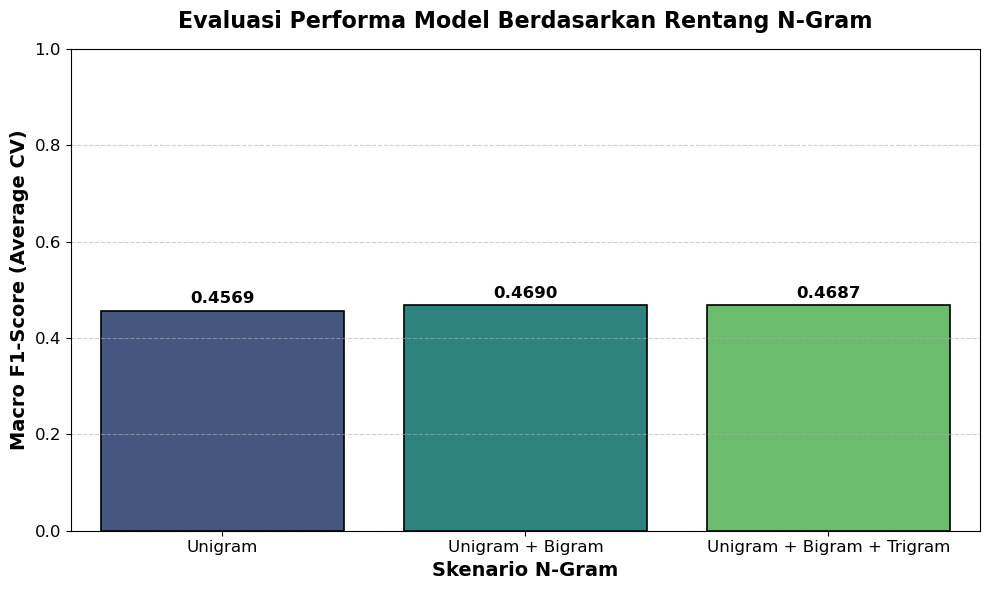

Kesimpulan: Kombinasi n-gram optimal untuk model adalah (1, 2)


In [ ]:
# --- 2.16 Eksperimen Optimalisasi N-Gram (Pipeline & Cross-Validation) ---

# Tahap ini bertujuan mencari kombinasi token (n-gram) terbaik dengan validasi yang ketat.
# Digunakan 'ImbPipeline' untuk memastikan SMOTE hanya dilakukan pada subset training
# guna menghindari 'Data Leakage' pada proses evaluasi.

# 1. Parameter Dasar Vectorizer
vec_params = {
    'min_df': 2,
    'max_df': 0.90,
    'sublinear_tf': True # Menggunakan penskalaan logaritmik untuk menekan frekuensi kata tinggi
}

# 2. Definisi Skenario N-Gram yang diuji
ngram_scenarios = {
    'Unigram': (1, 1),
    'Unigram + Bigram': (1, 2),
    'Unigram + Bigram + Trigram': (1, 3)
}

results = []
best_score_cv = 0
best_ngram_range = (1, 1)

print("=== MEMULAI PERBANDINGAN N-GRAM (ROBUST EVALUATION) ===")

for name, ngram in ngram_scenarios.items():
    print(f"Menguji skenario: {name}...")

    # A. Inisialisasi Pipeline: TF-IDF -> SMOTE -> Naive Bayes
    # Pipeline memastikan transformasi data dilakukan secara terisolasi di setiap fold CV.
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram, **vec_params)),
        ('smote', SMOTE(random_state=42, k_neighbors=3)), 
        ('clf', MultinomialNB())
    ])

    # B. Strategi Validasi: 10-Fold Stratified Cross-Validation
    # Membagi data latih menjadi 10 bagian untuk mendapatkan estimasi performa yang stabil.
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Menghitung skor Macro F1 (fokus pada performa tiap kelas sentimen)
    cv_scores = cross_val_score(pipe, X_train_text, y_train, cv=cv, scoring='f1_macro', n_jobs=-2)
    avg_score = cv_scores.mean()

    # C. Pencatatan Hasil
    results.append({'Skenario': name, 'Rata-rata CV Score': avg_score})
    print(f"--> Rata-rata Macro F1 Score: {avg_score:.4f}")

    # Identifikasi Skenario Terbaik
    if avg_score > best_score_cv:
        best_score_cv = avg_score
        best_ngram_range = ngram

# --- 2.17 Visualisasi dan Kesimpulan Perbandingan ---
print("\n=== RINGKASAN PERFORMA N-GRAM ===")
df_results = pd.DataFrame(results)
display(df_results)

# Visualisasi perbandingan 
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Skenario', 
    y='Rata-rata CV Score', 
    data=df_results, 
    palette='viridis', 
    hue='Skenario', 
    legend=False,
    edgecolor='black', 
    linewidth=1.2
    )

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=12, fontweight='bold')

plt.title('Evaluasi Performa Model Berdasarkan Rentang N-Gram', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Macro F1-Score (Average CV)', fontsize=14, fontweight='bold')
plt.xlabel('Skenario N-Gram', fontsize=14, fontweight='bold')

ax.tick_params(axis='both', labelsize=12)

plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Kesimpulan: Kombinasi n-gram optimal untuk model adalah {best_ngram_range}")

### Cek Penanganan Imbalance (SMOTE)

In [5]:
# --- 2.17 Ekstraksi dan Verifikasi Data Final (Post-SMOTE & N-Gram) ---

# 1. Inisialisasi Vectorizer dengan N-Gram Terbaik hasil turnamen
# Gunakan 'best_ngram_range' yang didapat dari tahap 2.17
final_vec = TfidfVectorizer(ngram_range=best_ngram_range, **vec_params)

# 2. Transformasi Teks Latih menjadi Matriks TF-IDF
X_train_tfidf = final_vec.fit_transform(X_train_text)

# 3. Aplikasi SMOTE secara Eksplisit (Untuk Dokumentasi Final)
# Kita lakukan SMOTE di luar pipeline hanya untuk verifikasi dimensi data akhir
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_tfidf, y_train)

# 4. Verifikasi Distribusi dan Dimensi
print("=== VERIFIKASI DATA FINAL SETELAH SMOTE & N-GRAM ===")
print(f"Kombinasi N-Gram yang digunakan : {best_ngram_range}")
print(f"Jumlah Fitur (Vocabulary)       : {len(final_vec.get_feature_names_out())}")
print("-" * 45)

# Menghitung distribusi kelas setelah penyeimbangan
dist_final = Counter(y_train_resampled)
print(f"Distribusi Label Final (y_train_resampled):")
for label, count in dist_final.items():
    # Menggunakan mapping LabelEncoder yang tadi (misal 0, 1, 2)
    print(f" - Kelas {label}: {count} sampel")

print("-" * 45)
print(f"Ukuran Matriks Fitur (X_train_resampled): {X_train_resampled.shape}")

=== VERIFIKASI DATA FINAL SETELAH SMOTE & N-GRAM ===
Kombinasi N-Gram yang digunakan : (1, 2)
Jumlah Fitur (Vocabulary)       : 7919
---------------------------------------------
Distribusi Label Final (y_train_resampled):
 - Kelas Positif: 14751 sampel
 - Kelas Netral: 14751 sampel
 - Kelas Negatif: 14751 sampel
---------------------------------------------
Ukuran Matriks Fitur (X_train_resampled): (44253, 7919)


# Tahap 3: Hyperparameter Tuning

=== TAHAP 3: TUNING PIPELINE (INTEGRATED OPTIMIZATION) ===
Konfigurasi Fitur: N-Gram (1, 2)
Sedang mencari kombinasi parameter optimal melalui iterasi sistematis...
Fitting 10 folds for each of 30 candidates, totalling 300 fits

HASIL OPTIMASI HYPERPARAMETER (FINAL)
Optimal SMOTE k_neighbors : 3
Optimal Alpha Smoothing   : 12.0
Optimal Fit Prior         : True
Skor Validasi (Macro F1)  : 0.4991


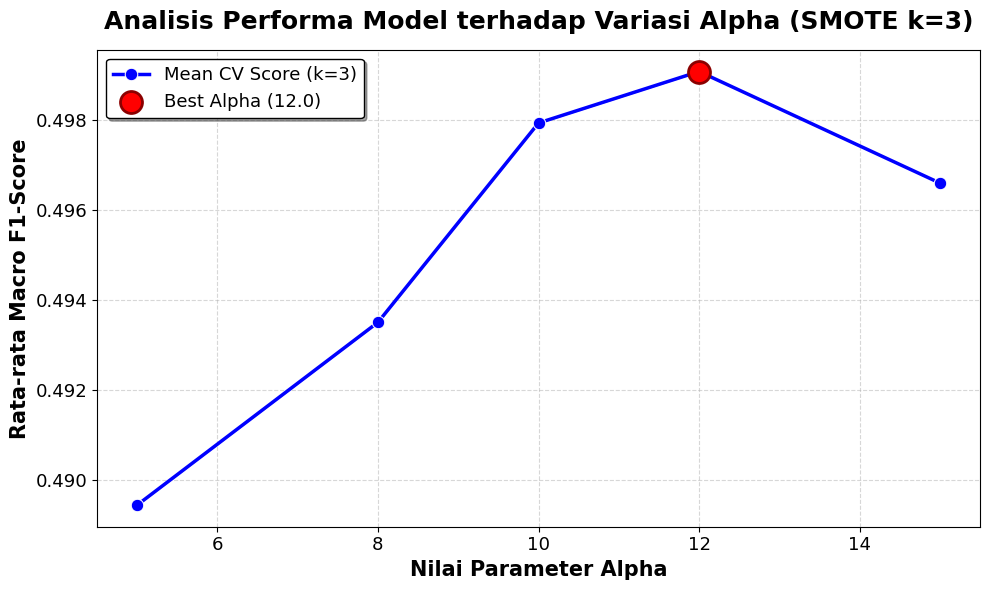

In [6]:
# ==============================================================================
# TAHAP 3: OPTIMASI MODEL (HYPERPARAMETER TUNING)
# ==============================================================================

# Tahap ini bertujuan untuk mencari parameter terbaik bagi algoritma SMOTE dan 
# Multinomial Naive Bayes guna meminimalisir bias dan memaksimalkan generalisasi model.

print("=== TAHAP 3: TUNING PIPELINE (INTEGRATED OPTIMIZATION) ===")
print(f"Konfigurasi Fitur: N-Gram {best_ngram_range}")

# 1. Konstruksi Pipeline Optimasi
# Pipeline dibangun untuk menjamin isolasi data pada setiap iterasi Cross-Validation.
pipeline_tuning = ImbPipeline([
    ('tfidf', TfidfVectorizer(ngram_range=best_ngram_range, **vec_params)),
    ('smote', SMOTE(random_state=42)), 
    ('clf', MultinomialNB())
])

# 2. Definisi Ruang Parameter (Parameter Grid)
# Menguji variasi k-neighbors untuk SMOTE dan nilai Smoothing Alpha untuk Naive Bayes.
param_grid = {
    'smote__k_neighbors': [3, 5, 7],      # Optimasi struktur sintetis data minoritas
    'clf__alpha': [5.0, 8.0, 10.0, 12.0, 15.0], # Optimasi Laplace/Lidstone Smoothing
    'clf__fit_prior': [True, False]       # Optimasi pengaruh probabilitas kelas awal
}

# 3. Inisialisasi Grid Search dengan 10-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=pipeline_tuning,
    param_grid=param_grid,
    cv=10, 
    scoring='f1_macro', 
    n_jobs=-2, 
    verbose=1
)

# 4. Pelatihan Model Tuning (Fit pada Data Latih)
print("Sedang mencari kombinasi parameter optimal melalui iterasi sistematis...")
grid_search.fit(X_train_text, y_train)

# 5. Ekstraksi Konfigurasi Terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "="*50)
print("HASIL OPTIMASI HYPERPARAMETER (FINAL)")
print("="*50)
print(f"Optimal SMOTE k_neighbors : {best_params['smote__k_neighbors']}")
print(f"Optimal Alpha Smoothing   : {best_params['clf__alpha']}")
print(f"Optimal Fit Prior         : {best_params['clf__fit_prior']}")
print(f"Skor Validasi (Macro F1)  : {best_score:.4f}")

# Menyimpan pipeline model terbaik untuk tahap evaluasi akhir
best_model_pipeline = grid_search.best_estimator_

# --- 3.1 Visualisasi Analisis Sensitivitas Parameter ---
results_df = pd.DataFrame(grid_search.cv_results_)
best_k = best_params['smote__k_neighbors']
filtered_df = results_df[results_df['param_smote__k_neighbors'] == best_k].copy()
filtered_df['param_clf__alpha'] = filtered_df['param_clf__alpha'].astype(float)

plt.figure(figsize=(10, 6))

sns.lineplot(data=filtered_df, x='param_clf__alpha', y='mean_test_score', 
             marker='o', color='blue', linewidth=2.5, markersize=9, 
             label=f'Mean CV Score (k={best_k})')

plt.scatter(best_params['clf__alpha'], best_score, 
            color='red', s=250, zorder=5, edgecolor='darkred', linewidth=2,  
            label=f"Best Alpha ({best_params['clf__alpha']})")

plt.title(f'Analisis Performa Model terhadap Variasi Alpha (SMOTE k={best_k})', 
          fontsize=18, fontweight='bold', pad=15)  

plt.xlabel('Nilai Parameter Alpha', fontsize=15, fontweight='bold') 
plt.ylabel('Rata-rata Macro F1-Score', fontsize=15, fontweight='bold') 

plt.tick_params(axis='both', labelsize=13) 

plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, edgecolor='black') 

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Tahap 4: Evaluasi Final & Komparasi Skenario

=== MEMULAI ANALISIS MULTI-SKENARIO (TOTAL 5 PENGUJIAN) ===

[1/5] Running Skenario 1: Baseline (Kondisi Awal)...

[2/5] Running Skenario 2: Integrasi Preprocessing...

[3/5] Running Skenario 3: Integrasi N-Gram (1, 2)...

[4/5] Running Skenario 4: Integrasi SMOTE Resampling...

[5/5] Running Skenario 5: Integrasi Hyperparameter Tuning...

HASIL KOMPARASI AKHIR PENELITIAN


,Skenario,Macro F1,Akurasi
0,1. Baseline,0.321020,0.928751
1,2. Preprocessing,0.367301,0.930514
2,3. Fitur N-Gram,0.327838,0.929003
3,4. Resampling,0.476124,0.806395
4,5. Final Tuning,0.502379,0.850705


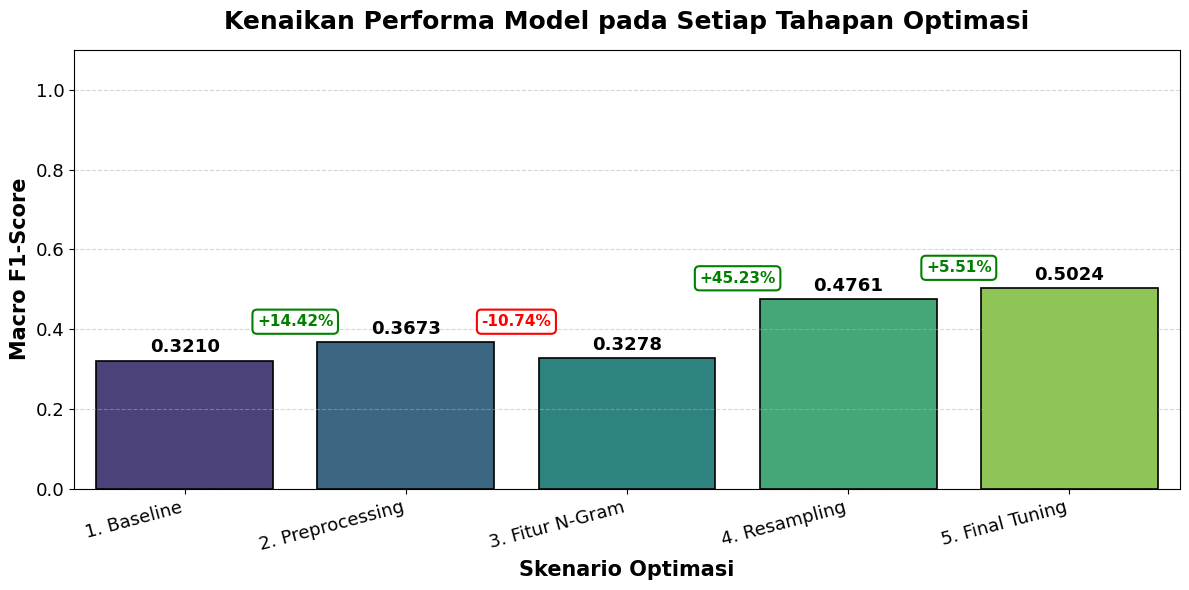

In [49]:
# ==============================================================================
# TAHAP 4: EVALUASI KOMPARATIF (ABLATION STUDY - 5 SKENARIO)
# ==============================================================================

# Tahap ini bertujuan untuk mengukur kontribusi setiap komponen sistem terhadap
# peningkatan performa model secara keseluruhan.

komparasi_results = []

print("=== MEMULAI ANALISIS MULTI-SKENARIO (TOTAL 5 PENGUJIAN) ===")

# --- SKENARIO 1: BASELINE MODEL ---
# Menggunakan data mentah (raw), Unigram, tanpa penyeimbangan kelas, dan parameter default.
print("\n[1/5] Running Skenario 1: Baseline (Kondisi Awal)...")
vec_1 = TfidfVectorizer(tokenizer=lambda x: x.split(), token_pattern=None, lowercase=False)
X_train_1 = vec_1.fit_transform(X_train_raw) 
X_test_1 = vec_1.transform(X_test_raw)

mnb_1 = MultinomialNB() # Default Alpha=1.0
mnb_1.fit(X_train_1, y_train)
pred_1 = mnb_1.predict(X_test_1)

komparasi_results.append({
    'Skenario': '1. Baseline',
    'Macro F1': f1_score(y_test, pred_1, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_1)
})

# --- SKENARIO 2: IMPACT OF PREPROCESSING ---
# Menambahkan tahap Normalisasi Slang dan Stemming (Unigram + Default NB).
print("\n[2/5] Running Skenario 2: Integrasi Preprocessing...")
vec_2 = TfidfVectorizer(ngram_range=(1,1), **vec_params)
X_train_2 = vec_2.fit_transform(X_train_text) 
X_test_2 = vec_2.transform(X_test_text)

mnb_2 = MultinomialNB().fit(X_train_2, y_train)
pred_2 = mnb_2.predict(X_test_2)

komparasi_results.append({
    'Skenario': '2. Preprocessing',
    'Macro F1': f1_score(y_test, pred_2, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_2)
})

# --- SKENARIO 3: IMPACT OF N-GRAM FEATURES ---
# Menggunakan rentang N-Gram optimal hasil tunamen di Tahap 2.
print(f"\n[3/5] Running Skenario 3: Integrasi N-Gram {best_ngram_range}...")
vec_3 = TfidfVectorizer(ngram_range=best_ngram_range, **vec_params)
X_train_3 = vec_3.fit_transform(X_train_text)
X_test_3 = vec_3.transform(X_test_text)

mnb_3 = MultinomialNB().fit(X_train_3, y_train)
pred_3 = mnb_3.predict(X_test_3)

komparasi_results.append({
    'Skenario': '3. Fitur N-Gram',
    'Macro F1': f1_score(y_test, pred_3, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_3)
})

# --- SKENARIO 4: IMPACT OF CLASS RESAMPLING ---
# Menangani Imbalance Data menggunakan SMOTE (Default Parameter).
print("\n[4/5] Running Skenario 4: Integrasi SMOTE Resampling...")
smote_4 = SMOTE(random_state=42, k_neighbors=3)
X_train_4, y_train_4 = smote_4.fit_resample(X_train_3, y_train)

mnb_4 = MultinomialNB().fit(X_train_4, y_train_4)
pred_4 = mnb_4.predict(X_test_3)

komparasi_results.append({
    'Skenario': '4. Resampling',
    'Macro F1': f1_score(y_test, pred_4, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_4)
})

# --- SKENARIO 5: OPTIMASI FINAL (HYPERPARAMETER TUNING) ---
# Menggunakan konfigurasi Alpha dan k-neighbors terbaik hasil GridSearchCV.
print(f"\n[5/5] Running Skenario 5: Integrasi Hyperparameter Tuning...")
pred_5 = best_model_pipeline.predict(X_test_text)

komparasi_results.append({
    'Skenario': '5. Final Tuning',
    'Macro F1': f1_score(y_test, pred_5, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_5)
})

# --- 4.1 Visualisasi Komparasi Performa Keseluruhan ---
print("\n" + "="*55)
print("HASIL KOMPARASI AKHIR PENELITIAN")
print("="*55)
df_komparasi = pd.DataFrame(komparasi_results)
display(df_komparasi)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Skenario', y='Macro F1', data=df_komparasi, 
                 palette='viridis', hue='Skenario', legend=False,
                 edgecolor='black', linewidth=1.2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=13, fontweight='bold')

# TAMBAHKAN ANGKA PERUBAHAN ANTAR SKENARIO
for i in range(1, len(df_komparasi)):
    prev_val = df_komparasi.iloc[i-1]['Macro F1']
    curr_val = df_komparasi.iloc[i]['Macro F1']
    change = ((curr_val - prev_val) / prev_val) * 100
    
    if abs(change) > 0.01:  # Threshold kecil karena perubahan mungkin kecil
        color = 'green' if change > 0 else 'red'
        sign = '+' if change > 0 else ''
        
        # Posisi di antara 2 bar
        x_pos = (i - 1 + i) / 2
        y_pos = max(prev_val, curr_val) + 0.04
        
        ax.text(x_pos, y_pos, f'{sign}{change:.2f}%',
                ha='center', fontsize=11, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=color, linewidth=1.5))

plt.title('Kenaikan Performa Model pada Setiap Tahapan Optimasi', 
          fontsize=18, fontweight='bold', pad=15)

plt.ylabel('Macro F1-Score', fontsize=15, fontweight='bold')
plt.xlabel('Skenario Optimasi', fontsize=15, fontweight='bold')

ax.tick_params(axis='both', labelsize=13)

plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
def plot_2metric_comparison(configs, f1_values, acc_values, 
                            f1_improvement_pct, acc_improvement_pct,
                            title_prefix='Test Set Performance',
                            filename='comparison.png'):
    """
    Plot comparison untuk F1 dan Accuracy dalam 2 subplot
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    metrics = [
        {'name': 'Macro F1', 'values': f1_values, 'improvement': f1_improvement_pct, 
         'ylabel': 'Macro F1-Score'},
        {'name': 'Accuracy', 'values': acc_values, 'improvement': acc_improvement_pct, 
         'ylabel': 'Accuracy'}
    ]
    
    for idx, metric in enumerate(metrics):
        # Plot
        sns.barplot(x=configs, y=metric['values'], palette='viridis', 
                    hue=configs, ax=axes[idx], legend=False)
        
        # Styling
        axes[idx].set_ylabel(metric['ylabel'], fontsize=15, fontweight='bold')
        axes[idx].set_xlabel('Konfigurasi Model', fontsize=15, fontweight='bold')
        axes[idx].set_title(f"{title_prefix} ({metric['name']})", 
                            fontsize=18, fontweight='bold', pad=15)
        axes[idx].set_ylim(0, 1.0)
        axes[idx].tick_params(axis='both', labelsize=13)
        axes[idx].grid(axis='y', linestyle='--', alpha=0.5)
        
        # Bar labels
        for i, v in enumerate(metric['values']):
            axes[idx].text(i, v + 0.02, f'{v:.4f}', 
                           ha='center', fontweight='bold', fontsize=13)
        
        # Improvement percentage
        if abs(metric['improvement']) > 0.1:
            color = 'green' if metric['improvement'] > 0 else 'red'
            sign = '+' if metric['improvement'] > 0 else ''
            y_pos = max(metric['values']) + 0.05
            
            axes[idx].text(0.5, y_pos, f"{sign}{metric['improvement']:.2f}%",
                           ha='center', fontsize=12, color=color, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                    edgecolor=color, linewidth=1.5))
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualisasi disimpan sebagai '{filename}'")

=== MEMULAI ANALISIS ABLASI:  WITH vs WITHOUT SLANG NORMALIZATION ===

[1/2] Memuat dataset WITHOUT slang normalization...
Jumlah data valid (NO slang): 19923
Train set: 15938 | Test set: 3985

[2/2] Vectorisasi & Training model (NO slang normalization)...

HASIL ANALISIS ABLASI:  DAMPAK NORMALISASI SLANG


,preprocessing,vocabulary_size,macro_f1,accuracy
0,WITH Slang Normalization,2711,0.367301,0.930514
1,WITHOUT Slang Normalization,2809,0.343854,0.927478



KESIMPULAN ANALISIS ABLASI
Reduksi Vocabulary     :  98 kata (3.49%)
Peningkatan Macro F1   : 0.0234 (+6.82%)
Peningkatan Accuracy   : 0.0030

PERBANDINGAN:   WITH vs WITHOUT SLANG NORMALIZATION


,preprocessing,vocabulary_size,macro_f1,accuracy
0,WITH Slang Normalization,2711,0.367301,0.930514
1,WITHOUT Slang Normalization,2809,0.343854,0.927478


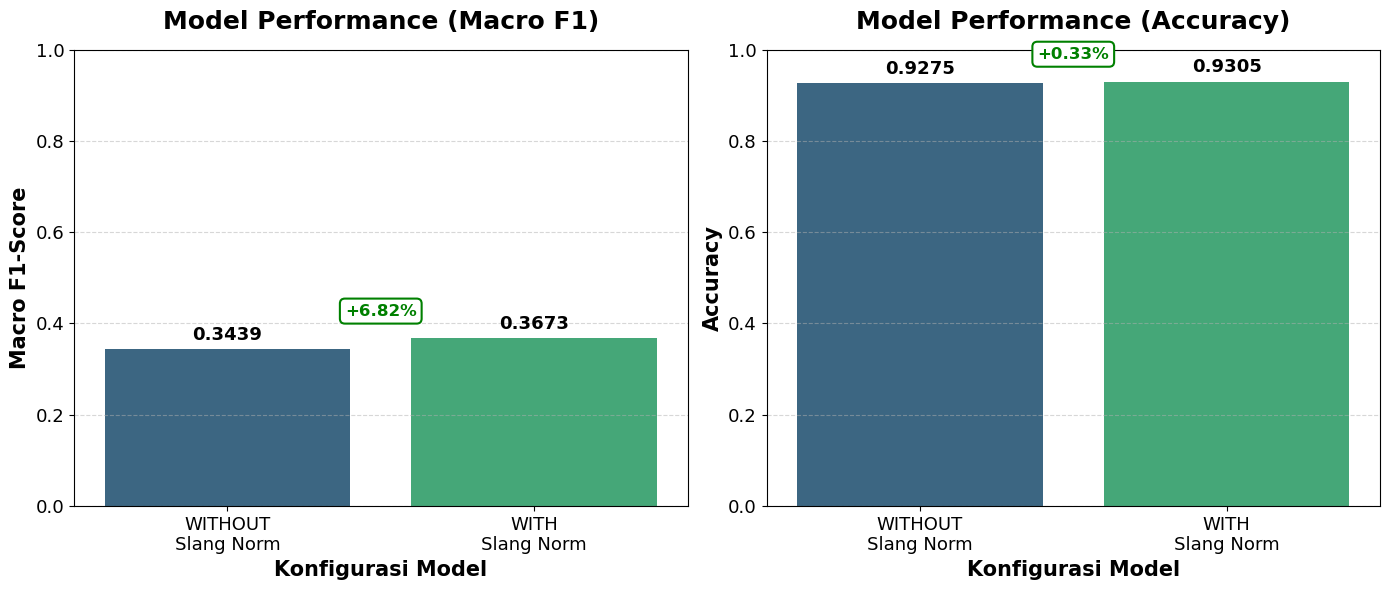

Visualisasi disimpan sebagai 'comparison_slang_norm.png'

Analisis ablasi selesai.


In [ ]:
# ==============================================================================
#  ANALISIS ABLASI - DAMPAK NORMALISASI SLANG TERHADAP PERFORMA MODEL
# ==============================================================================

print("=== MEMULAI ANALISIS ABLASI:  WITH vs WITHOUT SLANG NORMALIZATION ===\n")

# Simpan hasil model current (WITH slang) dari training sebelumnya
results_with_slang = {
    'preprocessing':  'WITH Slang Normalization',
    'vectorizer': vec_2,
    'vocabulary_size': len(vec_2.get_feature_names_out()),
    'macro_f1': f1_score(y_test, pred_2, average='macro'),
    'accuracy': accuracy_score(y_test, pred_2)
}

# --- LOAD DATASET WITHOUT SLANG (LANGSUNG DARI CSV) ---
print("[1/2] Memuat dataset WITHOUT slang normalization...")
df_no_slang = pd.read_csv('data_NO_slang_normalization.csv')

df_no_slang['text_final'] = df_no_slang['text_final'].astype(str)
df_no_slang = df_no_slang[df_no_slang['text_final'].str.strip() != '']
df_no_slang = df_no_slang. dropna(subset=['Sentiment_Label'])

print(f"Jumlah data valid (NO slang): {len(df_no_slang)}")

# Encoding label
le_no = LabelEncoder()
df_no_slang['label_encoded'] = le_no. fit_transform(df_no_slang['Sentiment_Label'])

# Split data dengan random_state SAMA agar fair comparison
X_no = df_no_slang['text_final']
y_no = df_no_slang['label_encoded']

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_no, y_no, test_size=0.2, random_state=42, stratify=y_no
)

print(f"Train set: {len(X_train_no)} | Test set: {len(X_test_no)}")

# --- VECTORISASI & TRAINING ---
print("\n[2/2] Vectorisasi & Training model (NO slang normalization)...")

vec_no_slang = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

X_train_vec_no = vec_no_slang.fit_transform(X_train_no)
X_test_vec_no = vec_no_slang.transform(X_test_no)

mnb_no_slang = MultinomialNB()
mnb_no_slang.fit(X_train_vec_no, y_train_no)

pred_no_slang = mnb_no_slang.predict(X_test_vec_no)

results_no_slang = {
    'preprocessing': 'WITHOUT Slang Normalization',
    'vectorizer': vec_no_slang,
    'vocabulary_size': len(vec_no_slang.get_feature_names_out()),
    'macro_f1': f1_score(y_test_no, pred_no_slang, average='macro'),
    'accuracy': accuracy_score(y_test_no, pred_no_slang)
}

# --- KOMPARASI HASIL ---
print("\n" + "="*70)
print("HASIL ANALISIS ABLASI:  DAMPAK NORMALISASI SLANG")
print("="*70)

df_ablation = pd.DataFrame([results_with_slang, results_no_slang])
df_ablation = df_ablation[['preprocessing', 'vocabulary_size', 'macro_f1', 'accuracy']]

display(df_ablation)

vocab_reduction = results_no_slang['vocabulary_size'] - results_with_slang['vocabulary_size']
f1_improvement = results_with_slang['macro_f1'] - results_no_slang['macro_f1']
f1_improvement_pct = (f1_improvement / results_no_slang['macro_f1']) * 100

print("\n" + "="*70)
print("KESIMPULAN ANALISIS ABLASI")
print("="*70)
print(f"Reduksi Vocabulary     : {vocab_reduction: ,} kata ({(vocab_reduction/results_no_slang['vocabulary_size']*100):.2f}%)")
print(f"Peningkatan Macro F1   : {f1_improvement:.4f} ({f1_improvement_pct:+.2f}%)")
print(f"Peningkatan Accuracy   : {results_with_slang['accuracy'] - results_no_slang['accuracy']:.4f}")

# --- VISUALISASI ---
print("\n" + "="*55)
print("PERBANDINGAN:   WITH vs WITHOUT SLANG NORMALIZATION")
print("="*55)

df_ablation_display = pd.DataFrame([results_with_slang, results_no_slang])
df_ablation_display = df_ablation_display[['preprocessing', 'vocabulary_size', 'macro_f1', 'accuracy']]
display(df_ablation_display)

prep_labels = ['WITHOUT\nSlang Norm', 'WITH\nSlang Norm']
f1_values = [results_no_slang['macro_f1'], results_with_slang['macro_f1']]
acc_values = [results_no_slang['accuracy'], results_with_slang['accuracy']]

# Hitung perubahan
f1_change = ((f1_values[1] - f1_values[0]) / f1_values[0]) * 100
acc_change = ((acc_values[1] - acc_values[0]) / acc_values[0]) * 100

# Panggil function
plot_2metric_comparison(
    configs=prep_labels,
    f1_values=f1_values,
    acc_values=acc_values,
    f1_improvement_pct=f1_change,
    acc_improvement_pct=acc_change,
    title_prefix='Model Performance',
    filename='comparison_slang_norm.png'
)

print("\nAnalisis ablasi selesai.")

=== ANALISIS:   PERFORMA UNIGRAM vs N-GRAM (SETELAH SMOTE) ===

Tujuan: Membuktikan kontribusi N-Gram pada data yang sudah diseimbangkan

[1/2] Training model:   SMOTE + Unigram...
   Test Macro F1:      0.4487
   Test Accuracy:       0.7845
   Vocabulary Size:     2,711 features

[2/2] Menggunakan hasil Skenario 4: SMOTE + N-Gram (1, 2)...
   Test Macro F1:      0.4761
   Test Accuracy:      0.8064
   Vocabulary Size:    7,919 features

HASIL KOMPARASI:  UNIGRAM vs N-GRAM (SETELAH SMOTE)


,Konfigurasi,Vocabulary Size,Test Macro F1,Test Accuracy
0,"SMOTE + Unigram (1,1)",2711,0.448705,0.784491
1,"SMOTE + N-Gram (1, 2)",7919,0.476124,0.806395



ANALISIS PENINGKATAN PERFORMA
Penambahan Vocabulary   : +5,208 features (+192.11%)
Peningkatan Test F1     : +0.0274 (+6.11%)
Peningkatan Accuracy    : +0.0219 (+2.79%)

=== VISUALISASI PERBANDINGAN ===



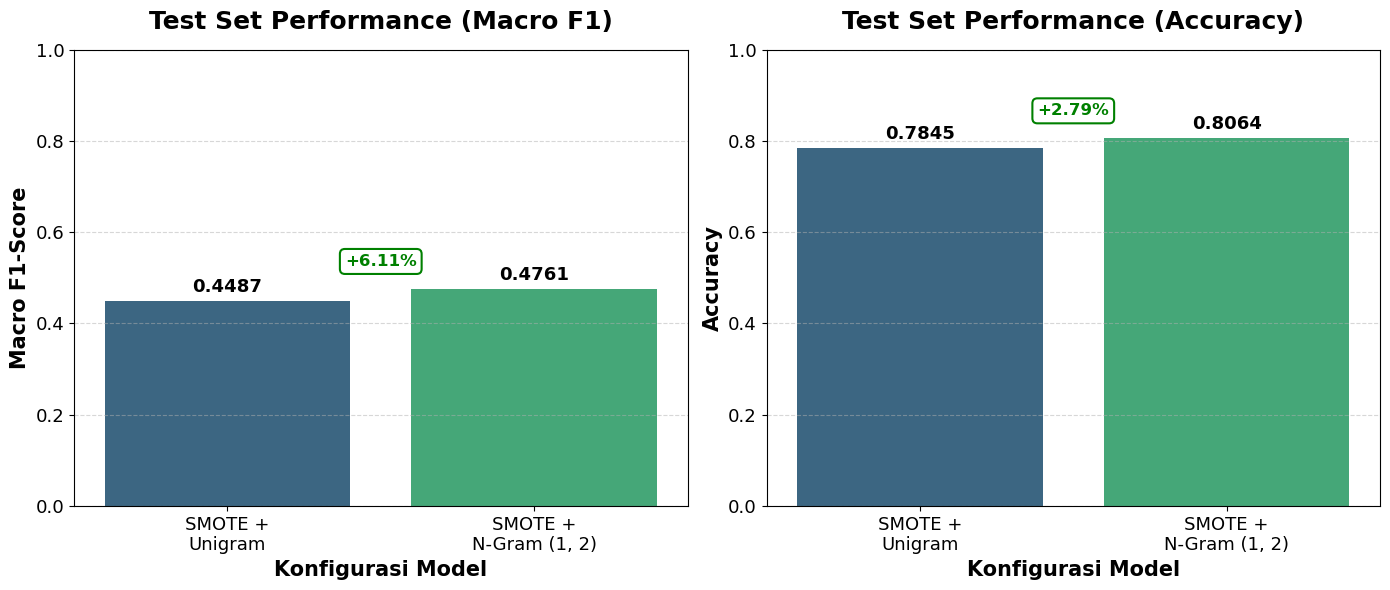

Visualisasi disimpan sebagai 'comparison_smote_unigram_vs_ngram.png'

CLASSIFICATION REPORT:   SMOTE + UNIGRAM
              precision    recall  f1-score   support

     Negatif       0.19      0.71      0.30        97
      Netral       0.11      0.32      0.16       186
     Positif       0.97      0.81      0.88      3689

    accuracy                           0.78      3972
   macro avg       0.42      0.61      0.45      3972
weighted avg       0.91      0.78      0.84      3972


CLASSIFICATION REPORT:   SMOTE + N-GRAM (1, 2)
              precision    recall  f1-score   support

     Negatif       0.22      0.69      0.34        97
      Netral       0.13      0.37      0.19       186
     Positif       0.98      0.83      0.90      3689

    accuracy                           0.81      3972
   macro avg       0.44      0.63      0.48      3972
weighted avg       0.92      0.81      0.85      3972


KESIMPULAN ANALISIS
Penambahan N-Gram (1, 2) pada model yang sudah menggunakan

In [42]:
# =============================================================================
# ANALISIS KOMPARATIF:   DAMPAK N-GRAM TERHADAP MODEL SETELAH SMOTE
# =============================================================================
print("=== ANALISIS:   PERFORMA UNIGRAM vs N-GRAM (SETELAH SMOTE) ===\n")
print("Tujuan: Membuktikan kontribusi N-Gram pada data yang sudah diseimbangkan\n")

# --- SKENARIO A:   SMOTE + UNIGRAM (Baseline Post-SMOTE) ---
print("[1/2] Training model:   SMOTE + Unigram...")

# 1. Buat vectorizer Unigram
vec_smote_unigram = TfidfVectorizer(ngram_range=(1, 1), **vec_params)
X_train_smote_unigram = vec_smote_unigram.fit_transform(X_train_text)
X_test_smote_unigram = vec_smote_unigram.transform(X_test_text)

# 2. Aplikasi SMOTE
smote_unigram = SMOTE(random_state=42, k_neighbors=3)
X_train_smote_unigram_resampled, y_train_smote_unigram = smote_unigram.fit_resample(
    X_train_smote_unigram, y_train
)

# 3. Training model
mnb_smote_unigram = MultinomialNB()
mnb_smote_unigram.fit(X_train_smote_unigram_resampled, y_train_smote_unigram)

# 4. Prediksi & Evaluasi
pred_smote_unigram = mnb_smote_unigram.predict(X_test_smote_unigram)

f1_smote_unigram = f1_score(y_test, pred_smote_unigram, average='macro')
acc_smote_unigram = accuracy_score(y_test, pred_smote_unigram)
vocab_size_unigram = len(vec_smote_unigram.get_feature_names_out())

print(f"   Test Macro F1:      {f1_smote_unigram:.4f}")
print(f"   Test Accuracy:       {acc_smote_unigram:.4f}")
print(f"   Vocabulary Size:    {vocab_size_unigram: ,} features\n")


# --- SKENARIO B:   SMOTE + N-GRAM (GUNAKAN HASIL SKENARIO 4 YANG SUDAH ADA) ---
print(f"[2/2] Menggunakan hasil Skenario 4: SMOTE + N-Gram {best_ngram_range}...")

# Gunakan hasil dari Skenario 4 (sudah di-train)
f1_smote_ngram = f1_score(y_test, pred_4, average='macro')  # pred_4 dari Skenario 4
acc_smote_ngram = accuracy_score(y_test, pred_4)
vocab_size_ngram = len(vec_3.get_feature_names_out())  # vec_3 dari Skenario 3

print(f"   Test Macro F1:      {f1_smote_ngram:.4f}")
print(f"   Test Accuracy:      {acc_smote_ngram:.4f}")
print(f"   Vocabulary Size:    {vocab_size_ngram:,} features\n")


# =============================================================================
# RINGKASAN KOMPARASI
# =============================================================================
print("=" * 75)
print("HASIL KOMPARASI:  UNIGRAM vs N-GRAM (SETELAH SMOTE)")
print("=" * 75)

comparison_smote = pd.DataFrame([
    {
        'Konfigurasi': 'SMOTE + Unigram (1,1)',
        'Vocabulary Size': vocab_size_unigram,
        'Test Macro F1': f1_smote_unigram,
        'Test Accuracy': acc_smote_unigram
    },
    {
        'Konfigurasi': f'SMOTE + N-Gram {best_ngram_range}',
        'Vocabulary Size': vocab_size_ngram,
        'Test Macro F1': f1_smote_ngram,
        'Test Accuracy': acc_smote_ngram
    }
])

display(comparison_smote)

# --- Hitung Peningkatan ---
vocab_increase = vocab_size_ngram - vocab_size_unigram
vocab_increase_pct = (vocab_increase / vocab_size_unigram) * 100

f1_improvement = f1_smote_ngram - f1_smote_unigram
f1_improvement_pct = (f1_improvement / f1_smote_unigram) * 100

acc_improvement = acc_smote_ngram - acc_smote_unigram
acc_improvement_pct = (acc_improvement / acc_smote_unigram) * 100

print("\n" + "=" * 75)
print("ANALISIS PENINGKATAN PERFORMA")
print("=" * 75)
print(f"Penambahan Vocabulary   : +{vocab_increase:,} features ({vocab_increase_pct:+.2f}%)")
print(f"Peningkatan Test F1     : {f1_improvement:+.4f} ({f1_improvement_pct:+.2f}%)")
print(f"Peningkatan Accuracy    : {acc_improvement:+.4f} ({acc_improvement_pct:+.2f}%)")
print("=" * 75)


# =============================================================================
# VISUALISASI PERBANDINGAN
# =============================================================================
print("\n=== VISUALISASI PERBANDINGAN ===\n")

configs = ['SMOTE +\nUnigram', f'SMOTE +\nN-Gram {best_ngram_range}']

plot_2metric_comparison(
    configs=configs,
    f1_values=[f1_smote_unigram, f1_smote_ngram],
    acc_values=[acc_smote_unigram, acc_smote_ngram],
    f1_improvement_pct=f1_improvement_pct,
    acc_improvement_pct=acc_improvement_pct,
    filename='comparison_smote_unigram_vs_ngram.png'
)

# =============================================================================
# CLASSIFICATION REPORT PERBANDINGAN
# =============================================================================
print("\n" + "=" * 75)
print("CLASSIFICATION REPORT:   SMOTE + UNIGRAM")
print("=" * 75)
print(classification_report(y_test, pred_smote_unigram, target_names=le. classes_))

print("\n" + "=" * 75)
print(f"CLASSIFICATION REPORT:   SMOTE + N-GRAM {best_ngram_range}")
print("=" * 75)
print(classification_report(y_test, pred_4, target_names=le.classes_))  # pred_4 dari Skenario 4


# =============================================================================
# KESIMPULAN
# =============================================================================
print("\n" + "=" * 75)
print("KESIMPULAN ANALISIS")
print("=" * 75)
print(f"Penambahan N-Gram {best_ngram_range} pada model yang sudah menggunakan SMOTE")
print(f"   menghasilkan peningkatan performa sebesar {f1_improvement_pct:.2f}% pada Test F1-Score")
print(f"\nVocabulary meningkat {vocab_increase_pct:.2f}% dengan penambahan {vocab_increase:,} fitur baru")
print(f"   yang menangkap konteks frasa (bigram/trigram)")
print(f"\nIni membuktikan bahwa kombinasi SMOTE + N-Gram menghasilkan")
print(f"   peningkatan performa terbesar dibanding menggunakan SMOTE saja")
print("=" * 75)

Membuktikan perlunya penanganan *imbalance* dan model *Baseline* (Skenario 1) itu "malas" dan hanya menebak kelas Positif (Mayoritas) aja.

In [10]:
# --- 4.2 Analisis Fenomena 'Majority Class Bias' (Baseline vs Final) ---

# Analisis ini bertujuan membuktikan secara empiris kenapa model Baseline (Skenario 1) 
# gagal dalam klasifikasi sentimen meskipun nilai akurasinya mungkin terlihat tinggi.

print("=== ANALISIS PERBANDINGAN DISTRIBUSI PREDIKSI ===")

# 1. Menampilkan Distribusi Label Aktual pada Data Uji (Ground Truth)
# Digunakan sebagai standar referensi distribusi yang seharusnya dicapai model.
print("\n[1] Distribusi Label Aktual (Data Uji):")
print(y_test.value_counts().sort_index())

# 2. Menampilkan Distribusi Tebakan Baseline (Skenario 1)
# Membuktikan adanya bias di mana model cenderung hanya menebak kelas mayoritas (Positif).
print("\n[2] Distribusi Prediksi Baseline (Skenario 1):")
print(pd.Series(pred_1).value_counts().sort_index())
# Analisis: Jika hasil hanya didominasi satu kelas, model mengalami 'Majority Class Bias'.

# 3. Menampilkan Distribusi Tebakan Model Final (Skenario 5)
# Membuktikan bahwa model sudah mampu mengenali karakteristik kelas minoritas (Negatif/Netral).
print("\n[3] Distribusi Prediksi Final (Skenario 5):")
print(pd.Series(pred_5).value_counts().sort_index())
# Analisis: Sebaran yang lebih merata menunjukkan efektivitas SMOTE dan Tuning.

=== ANALISIS PERBANDINGAN DISTRIBUSI PREDIKSI ===

[1] Distribusi Label Aktual (Data Uji):
Sentiment_Label
Negatif      97
Netral      186
Positif    3689
Name: count, dtype: int64

[2] Distribusi Prediksi Baseline (Skenario 1):
Positif    3972
Name: count, dtype: int64

[3] Distribusi Prediksi Final (Skenario 5):
Negatif     307
Netral      320
Positif    3345
Name: count, dtype: int64


Menunjukkan keunggulan metode *Preprocessing* dan *Filtering* dan membuktikan Skenario 2 & 3 itu "hemat memori" dibanding Skenario 1.

=== ANALISIS EFISIENSI RUANG FITUR ===
Total Fitur Awal (Baseline) : 19444 token
Total Fitur Akhir (Optimal) : 7919 token
Persentase Reduksi Dimensi  : 59.27%


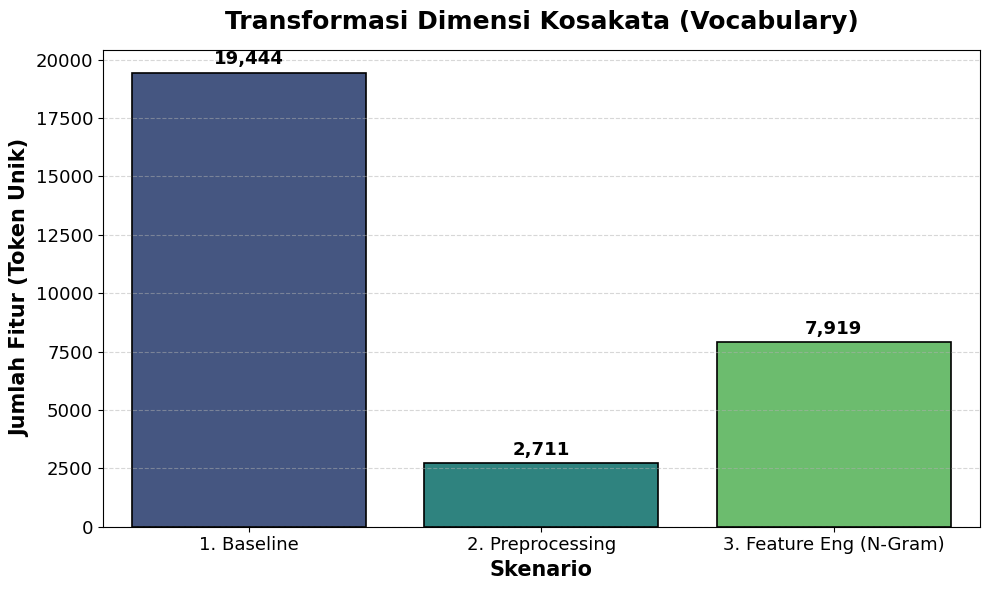

In [46]:
# --- 4.3 Analisis Efisiensi Dimensi Fitur (Vocabulary Reduction Analysis) ---

# Analisis ini mengukur efektivitas tahap preprocessing dalam mereduksi noise 
# dan redundansi pada ruang fitur (feature space).

vocab_stats = [
    {'Skenario': '1. Baseline', 'Jumlah Fitur': len(vec_1.vocabulary_)},
    {'Skenario': '2. Preprocessing', 'Jumlah Fitur': len(vec_2.vocabulary_)},
    {'Skenario': '3. Feature Eng (N-Gram)', 'Jumlah Fitur': len(vec_3.vocabulary_)},
]

df_vocab = pd.DataFrame(vocab_stats)

# 1. Kalkulasi Persentase Efisiensi
# Membandingkan jumlah fitur awal yang kotor dengan fitur akhir yang sudah teroptimasi
baseline_count = df_vocab.iloc[0]['Jumlah Fitur']
final_count = df_vocab.iloc[2]['Jumlah Fitur']
efisiensi = ((baseline_count - final_count) / baseline_count) * 100

print(f"=== ANALISIS EFISIENSI RUANG FITUR ===")
print(f"Total Fitur Awal (Baseline) : {baseline_count} token")
print(f"Total Fitur Akhir (Optimal) : {final_count} token")
print(f"Persentase Reduksi Dimensi  : {efisiensi:.2f}%")

# 2. Visualisasi Perbandingan Dimensi
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Skenario', 
    y='Jumlah Fitur', 
    data=df_vocab, 
    palette='viridis',  
    hue='Skenario',
    legend=False,
    edgecolor='black',
    linewidth=1.2
)

for c in ax.containers: 
    labels = [f'{int(v.get_height()):,}' for v in c]  
    ax.bar_label(c, labels=labels, padding=3, fontsize=13, fontweight='bold') 

plt.title('Transformasi Dimensi Kosakata (Vocabulary)', 
          fontsize=18, fontweight='bold', pad=15) 

plt.ylabel('Jumlah Fitur (Token Unik)', fontsize=15, fontweight='bold')
plt.xlabel('Skenario', fontsize=15, fontweight='bold') 

ax.tick_params(axis='both', labelsize=13) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**<h3>Visualisasi Confusion Matrix</h3>**
Memperlihatkan secara visual bahwa model Final berhasil mendeteksi kotak "Negatif dan "Netral", serta melihat seberapa banyak model "salah tebak" untuk dibandingkan Sebelum (Baseline) vs Sesudah (Final).

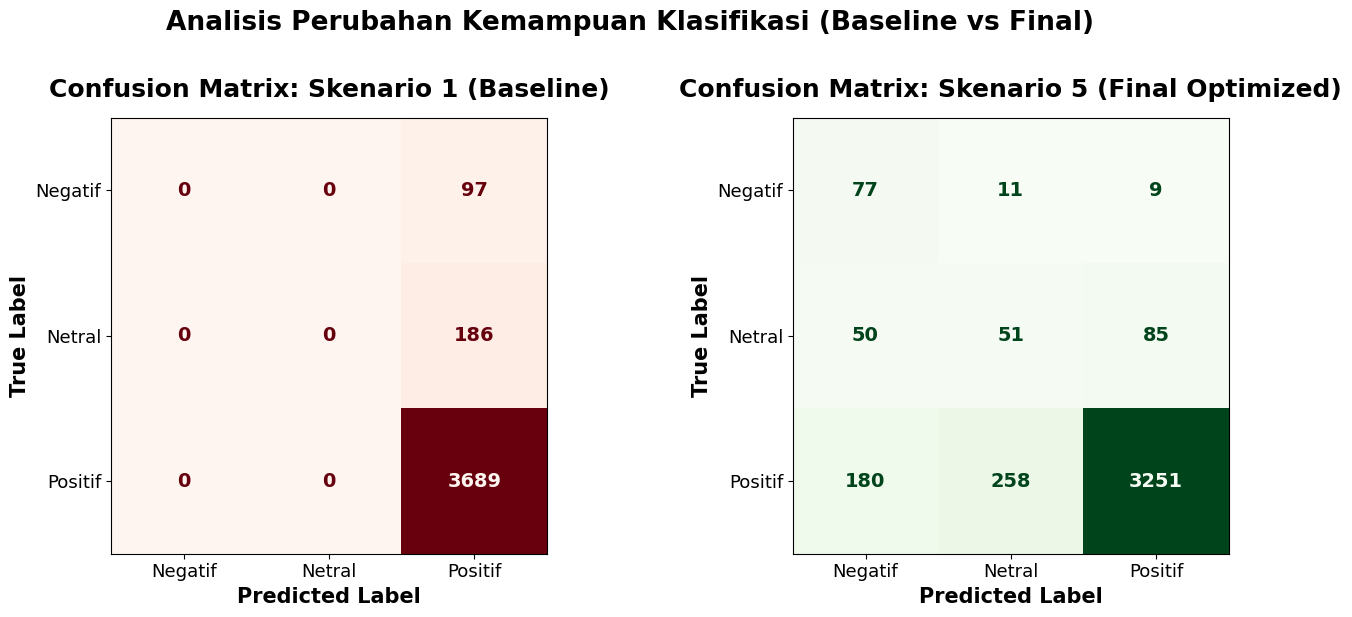

In [ ]:
# --- 4.4 Analisis Perbandingan Matriks Kebingungan (Confusion Matrix Comparison) ---

# Visualisasi komparatif antara model awal (Baseline) dan model akhir (Final)
# untuk membuktikan peningkatan kemampuan model dalam mengenali setiap kelas sentimen.

# Menetapkan urutan label yang konsisten untuk perbandingan yang adil
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

labels = ['Negatif', 'Netral', 'Positif']

# --- Skenario 1 (Baseline) ---
cm_1 = confusion_matrix(y_test, pred_1, labels=labels)
disp_1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=labels)
disp_1.plot(cmap='Reds', ax=ax[0], colorbar=False)

ax[0].set_title('Confusion Matrix: Skenario 1 (Baseline)', 
                fontsize=18, fontweight='bold', pad=15)  
ax[0].set_xlabel('Predicted Label', fontsize=15, fontweight='bold')  
ax[0].set_ylabel('True Label', fontsize=15, fontweight='bold')  
ax[0].tick_params(axis='both', labelsize=13) 

for text in disp_1.text_.ravel():
    text.set_fontsize(14)  
    text.set_fontweight('bold')

# --- Skenario 5 (Final) ---
cm_5 = confusion_matrix(y_test, pred_5, labels=labels)
disp_5 = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=labels)
disp_5.plot(cmap='Greens', ax=ax[1], colorbar=False)

ax[1].set_title('Confusion Matrix: Skenario 5 (Final Optimized)', 
                fontsize=18, fontweight='bold', pad=15) 
ax[1].set_xlabel('Predicted Label', fontsize=15, fontweight='bold')  
ax[1].set_ylabel('True Label', fontsize=15, fontweight='bold')  
ax[1].tick_params(axis='both', labelsize=13) 

for text in disp_5.text_.ravel():
    text.set_fontsize(14) 
    text.set_fontweight('bold')

plt.suptitle('Analisis Perubahan Kemampuan Klasifikasi (Baseline vs Final)', 
             fontsize=19, fontweight='bold', y=1.02) 

plt.subplots_adjust(wspace=0.15)
plt.tight_layout()
plt.show()

**<h3>Insight Fitur: Kata apa yang paling "Positif" & "Negatif"</h3>**
Tujuannya untuk memvalidasi secara kualitatif (misalnya: membuktikan bahwa kata "rusak" benar-benar dianggap negatif oleh model)

=== ANALISIS FEATURE IMPORTANCE:    KATA PALING BERPENGARUH (3 SENTIMEN) ===

N-Gram Range yang digunakan: (1, 2)
Jumlah fitur: 7919
Kelas sentiment: ['Negatif' 'Netral' 'Positif']


🔹 Top 12 fitur untuk sentimen 'Negatif':
   1. tidak                          (log_prob: -4.7727)
   2. tidak sesuai                   (log_prob: -5.6631)
   3. barang                         (log_prob: -5.7364)
   4. barang tidak                   (log_prob: -5.8874)
   5. kirim                          (log_prob: -5.9602)
   6. pakai                          (log_prob: -6.0737)
   7. rusak                          (log_prob: -6.1182)
   8. kecewa                         (log_prob: -6.1478)
   9. tidak pakai                    (log_prob: -6.2863)
  10. sesuai                         (log_prob: -6.3014)
  11. barang rusak                   (log_prob: -6.5024)
  12. beli                           (log_prob: -6.5570)

🔹 Top 12 fitur untuk sentimen 'Netral':
   1. barang                         (log_prob: -5.

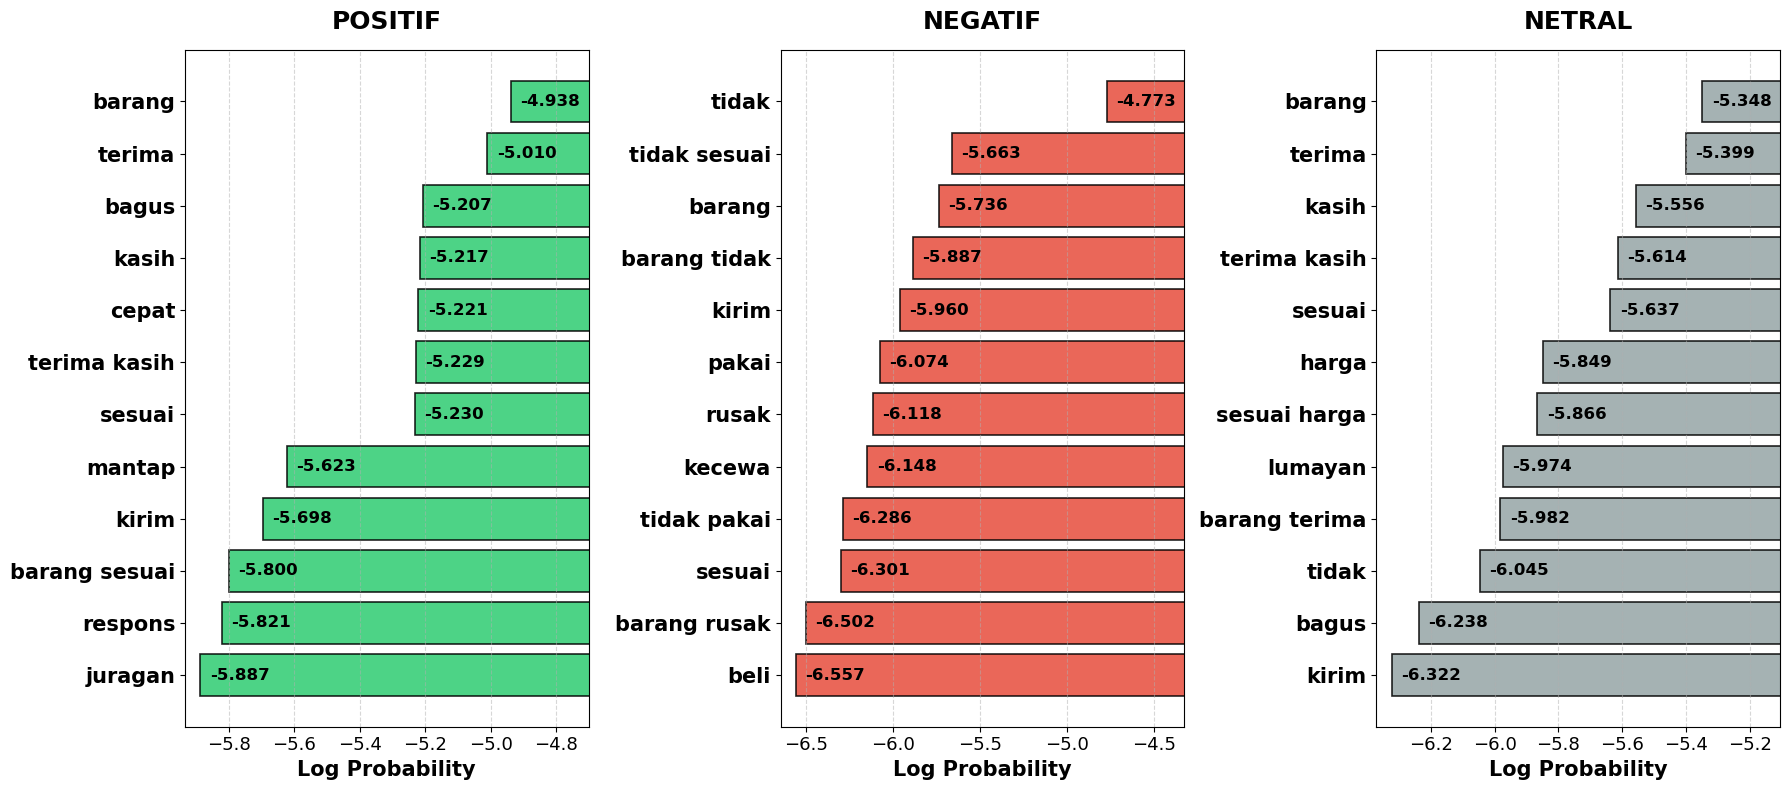


Visualisasi disimpan sebagai 'feature_importance_3sentimen_horizontal.png'
   (Menggunakan model final dengan N-Gram (1, 2))


In [ ]:
# =============================================================================
# INSIGHT FITUR:    Kata Paling "Positif", "Negatif", dan "Netral"
# =============================================================================
print("=== ANALISIS FEATURE IMPORTANCE:    KATA PALING BERPENGARUH (3 SENTIMEN) ===\n")

# UNAKAN MODEL FINAL (yang sudah pakai N-Gram optimal + Tuning)
# best_model_pipeline berisi:  TF-IDF (best_ngram_range) -> SMOTE -> MultinomialNB (tuned)

# Ekstrak vectorizer dan model dari pipeline terbaik
vectorizer = best_model_pipeline.named_steps['tfidf']  # TF-IDF dengan ngram optimal
model = best_model_pipeline.named_steps['clf']         # Multinomial NB yang sudah di-tune

# Ambil feature names (vocabulary)
feature_names = vectorizer. get_feature_names_out()

# Ambil log probability dari setiap kelas
log_prob = model.feature_log_prob_

# Mapping label ke nama kelas menggunakan LabelEncoder yang sudah ada
class_labels = le.inverse_transform([0, 1, 2])

print(f"N-Gram Range yang digunakan: {best_ngram_range}")
print(f"Jumlah fitur: {len(feature_names)}")
print(f"Kelas sentiment: {class_labels}\n")

# --- Ekstrak Top Features per Kelas ---
top_n = 12  # Ambil 12 kata/frasa teratas per kelas

top_features = {}
for i, label in enumerate(class_labels):
    # Ambil index kata dengan log_prob tertinggi untuk kelas ini
    top_indices = log_prob[i].argsort()[-top_n:][::-1]
    top_words = [(feature_names[idx], log_prob[i][idx]) for idx in top_indices]
    top_features[label] = top_words
    
    print(f"\n🔹 Top {top_n} fitur untuk sentimen '{label}':")
    for rank, (word, score) in enumerate(top_words, 1):
        print(f"  {rank:2d}. {word:30s} (log_prob: {score:.4f})")

# Visualisasi
print("\n" + "="*70)
print("VISUALISASI:  TOP FEATURES - 3 SENTIMEN (HORIZONTAL LAYOUT)")
print("="*70)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

colors_map = {
    'Positif': '#2ecc71',
    'Negatif': '#e74c3c',
    'Netral': '#95a5a6'
}

sentiment_order = ['Positif', 'Negatif', 'Netral']

for i, label in enumerate(sentiment_order):
    matching_label = None
    for cl in class_labels:
        if cl.lower() == label.lower():
            matching_label = cl
            break
    
    if matching_label is None or matching_label not in top_features:
        print(f"Warning: Label '{label}' tidak ditemukan, skip...")
        continue
    
    words = [word for word, _ in top_features[matching_label]]
    scores = [score for _, score in top_features[matching_label]]
    
    # Plot bar
    axes[i].barh(words, scores, height=0.8, color=colors_map[label], alpha=0.85,
                 edgecolor='black', linewidth=1.2)
    min_score = min(scores)
    max_score = max(scores)
    score_range = max_score - min_score
    axes[i].set_xlim(min_score - score_range * 0.05, max_score + score_range * 0.25)
    
    # Labels
    axes[i].set_xlabel('Log Probability', fontsize=15, fontweight='bold')  
    axes[i].set_title(f'{label.upper()}', fontsize=18, fontweight='bold', pad=15)  
    axes[i].invert_yaxis()
    
    # Ticks
    axes[i].tick_params(axis='y', labelsize=15) 
    axes[i].tick_params(axis='x', labelsize=13)
    for tick in axes[i].get_yticklabels():
        tick.set_fontweight('bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    for j, (word, score) in enumerate(zip(words, scores)): 
        axes[i].text(score + score_range * 0.03, j, f'{score:.3f}',  
                     va='center', ha='left', 
                     fontsize=12, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_3sentimen_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi disimpan sebagai 'feature_importance_3sentimen_horizontal.png'")
print(f"   (Menggunakan model final dengan N-Gram {best_ngram_range})")

=== ANALISIS KOMPARASI METRIK UTAMA ===
Macro F1        | 0.3210     | 0.5024     | +0.1814 (56.49%)
Akurasi         | 0.9288     | 0.8507     | -0.0780 (-8.40%)


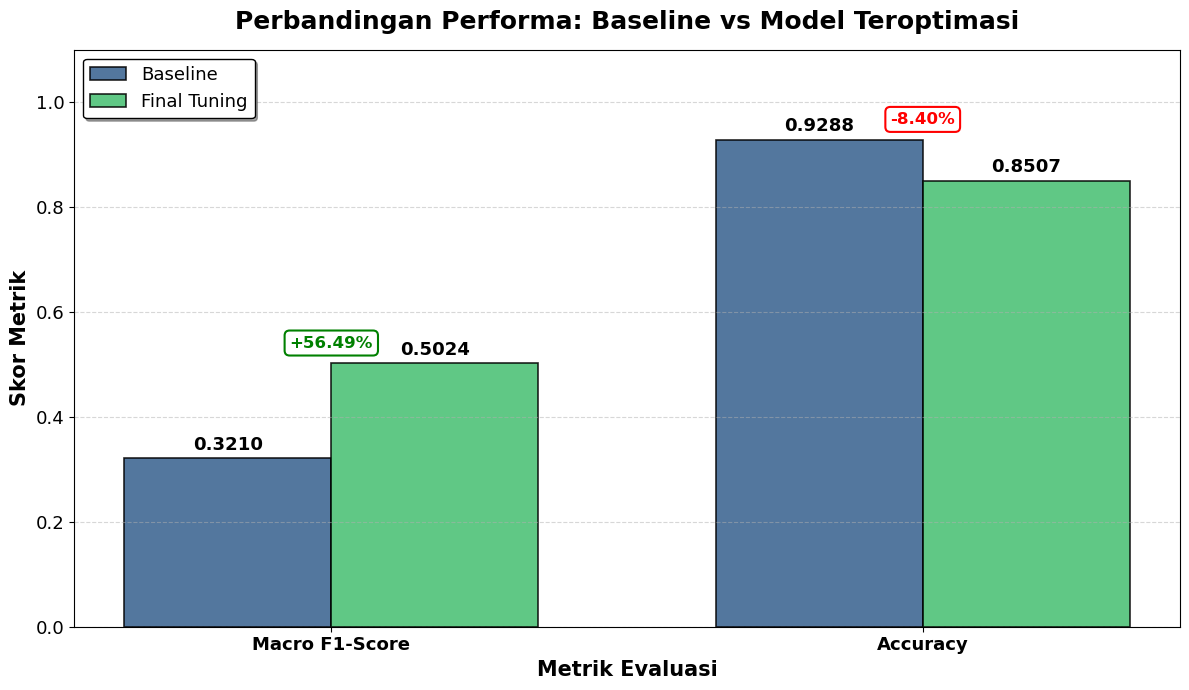

In [43]:
# ==============================================================================
# ANALISIS PENINGKATAN KINERJA (BASELINE VS FINAL TUNING)
# ==============================================================================

# 1. Ambil data dari variabel komparasi_results yang sudah dibuat di Tahap 4
baseline = df_komparasi[df_komparasi['Skenario'] == '1. Baseline'].iloc[0]
final = df_komparasi[df_komparasi['Skenario'] == '5. Final Tuning'].iloc[0]

# 2. Hitung Selisih Poin (Absolute Gain)
diff_f1 = final['Macro F1'] - baseline['Macro F1']
diff_acc = final['Akurasi'] - baseline['Akurasi']

# 3. Hitung Persentase Peningkatan (Relative Improvement)
improvement_f1 = (diff_f1 / baseline['Macro F1']) * 100
change_acc = (diff_acc / baseline['Akurasi']) * 100

print("=== ANALISIS KOMPARASI METRIK UTAMA ===")
print(f"{'Macro F1':<15} | {baseline['Macro F1']:<10.4f} | {final['Macro F1']:<10.4f} | {diff_f1:+.4f} ({improvement_f1:.2f}%)")
print(f"{'Akurasi':<15} | {baseline['Akurasi']:<10.4f} | {final['Akurasi']:<10.4f} | {diff_acc:+.4f} ({change_acc:+.2f}%)")

# --- 4.8 Visualisasi Delta Peningkatan ---
labels_metrik = ['Macro F1-Score', 'Accuracy']
baseline_vals = [baseline['Macro F1'], baseline['Akurasi']]
final_vals = [final['Macro F1'], final['Akurasi']]

x = np.arange(len(labels_metrik))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

viridis = plt.cm.viridis
colors = [viridis(0.3), viridis(0.7)] 

# Plot dengan warna viridis
rects1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', 
                color=colors[0], edgecolor='black', linewidth=1.2, alpha=0.85)  
rects2 = ax.bar(x + width/2, final_vals, width, label='Final Tuning', 
                color=colors[1], edgecolor='black', linewidth=1.2, alpha=0.85) 

ax.bar_label(rects1, padding=3, fmt='%.4f', fontsize=13, fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.4f', fontsize=13, fontweight='bold')

for i, (baseline, final) in enumerate(zip(baseline_vals, final_vals)):
    change = ((final - baseline) / baseline) * 100
    
    if abs(change) > 0.1:
        if change > 0:
            color = 'green'
            sign = '+'
        else:
            color = 'red'
            sign = ''
        
        y_pos = max(baseline, final) + 0.03
        
        ax.text(x[i], y_pos, f'{sign}{change:.2f}%',
                ha='center', fontsize=12, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor=color, linewidth=1.5))

ax.set_title('Perbandingan Performa: Baseline vs Model Teroptimasi', 
             fontsize=18, fontweight='bold', pad=15)

ax.set_ylabel('Skor Metrik', fontsize=15, fontweight='bold')
ax.set_xlabel('Metrik Evaluasi', fontsize=15, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_metrik, fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=13)

ax.set_ylim(0, 1.1)

ax.legend(fontsize=13, loc='upper left', frameon=True, shadow=True, 
          edgecolor='black')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 🏁 KESIMPULAN PENELITIAN (FINAL)

Berdasarkan seluruh tahapan eksperimen yang telah dilakukan pada dataset ulasan e-commerce, dapat ditarik beberapa kesimpulan utama sebagai berikut:

### 1. Keberhasilan Optimasi Model
* **Peningkatan Signifikan:** Penerapan optimasi melalui *preprocessing* (terutama **normalisasi slang** & stemming), fitur ***n*-gram**, penanganan *imbalanced data* (SMOTE) serta **optimasi parameter (Hyperparameter Tuning)** berhasil meningkatkan performa model secara drastis.
* **Metrik Utama:** Terjadi kenaikan **Macro F1-Score** sebesar **56.49%** (dari **0.3210** menjadi **0.5024**). Hal ini membuktikan bahwa kombinasi teknik tersebut berhasil membuat sistem jauh lebih cerdas dalam mengenali kelas minoritas (sentimen Negatif dan Netral) yang sebelumnya gagal terdeteksi oleh model *baseline*.

### 2. Analisis Trade-off Akurasi
* Terjadi penurunan akurasi sebesar **8.40%** (dari **92.88%** menjadi **85.07%**).
* **Analisis:** Penurunan ini merupakan **konsekuensi logis** dari penghapusan *Majority Class Bias*. Akurasi pada model *baseline* bersifat semu karena hanya condong pada kelas mayoritas, sedangkan model final memberikan hasil klasifikasi yang lebih adil dan representatif terhadap semua kelas sentimen.

### 3. Efisiensi Ruang Fitur
* Tahap *preprocessing* terbukti efektif dalam melakukan reduksi dimensi kosakata (*vocabulary reduction*) yang signifikan. Hal ini menunjukkan bahwa normalisasi bahasa informal berhasil menghilangkan redundansi data tanpa mengurangi muatan informasi/sentimen pada teks, sehingga komputasi menjadi lebih ringan.

### 4. Karakteristik Linguistik & Interpretabilitas
* Berdasarkan analisis *Feature Importance*, model berhasil mengidentifikasi kata kunci yang relevan secara semantik (contoh: kata 'kecewa', 'rusak' untuk sentimen negatif).
* Penggunaan **N-Gram (Bigram)** terbukti memberikan konteks tambahan yang krusial untuk menangkap makna negasi (misal: "tidak sesuai") yang sering muncul pada ulasan pelanggan.

---
**Rekomendasi Akhir:** Model Skenario 5 (Final Tuning) ditetapkan sebagai model terbaik untuk digunakan. Meskipun terdapat penurunan akurasi global, model ini memiliki keseimbangan (F1-Score) yang paling optimal dan mampu menggeneralisasi ulasan sentimen secara lebih akurat pada dataset yang tidak seimbang.